# Set UP


## Importing the BioXTAS API


In [1]:
import bioxtasraw.RAWAPI as raw
import bioxtasraw.RAWPlot as RAWPlot
import bioxtasraw.SASCalc as SASCalc


import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import glob
import os

from pptx import Presentation
from pptx.util import Inches
import tempfile

import imageio.v2 as imageio
import math

from scipy import optimize
from scipy import special



colorAA = 'orangered'

In [2]:
AA_hdf5='./data/AA_052024.hdf5'



Set Up SAXS Settings (from Brookhaven National Laboratory)

In [3]:
my_settings = raw.load_settings('/Applications/raw/docs/source/saxs/images/figure_data/SAXS.cfg')

/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/RAWSettings.py:935: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  settings = pickle_obj.load()


## Load Series from Hdf5 file *For SEC-SAXS 

In [4]:
#Define a list of series filenames to load
series_names = [AA_hdf5]

#Load the series
series = raw.load_series(series_names)
print(series)

In [5]:
my_series = series[0]

frames = my_series.getFrames()
print(frames)
total_i = my_series.getIntI()
print(total_i)
mean_i = my_series.getMeanI()


[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

Text(0, 0.5, 'Total I')

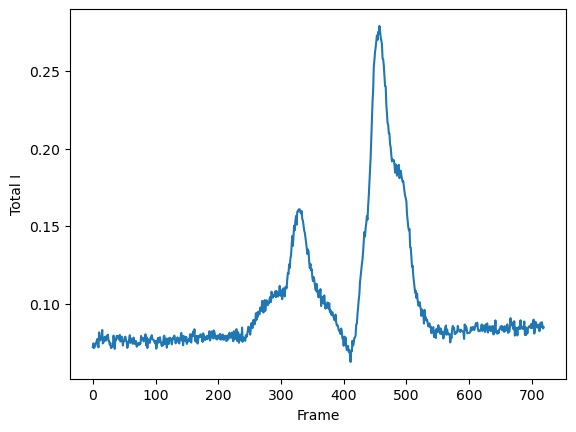

In [6]:
plt.plot(frames, total_i, label='Total I')
plt.xlabel('Frame')
plt.ylabel('Total I')

#### if only buffer subtraction is done

In [7]:
#Set buffer range
success, region_start, region_end = raw.find_buffer_range(my_series)
print(f"Buffer range found: {success}, start: {region_start}, end: {region_end}")
    
(sub_profiles, rg, rger, i0, i0er, vcmw, vcmwer,
    vpmw) = raw.set_buffer_range(my_series, [[region_start, region_end]])


Buffer range found: True, start: 182, end: 237


/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/SASCalc.py:258: RuntimeWarning: invalid value encountered in log10
  iratio = np.abs(np.log10(i0/i) - 2.25)


Baseline Corrected Series for ./data/AA_052024.hdf5:


Text(0, 0.5, 'Total Intensity')

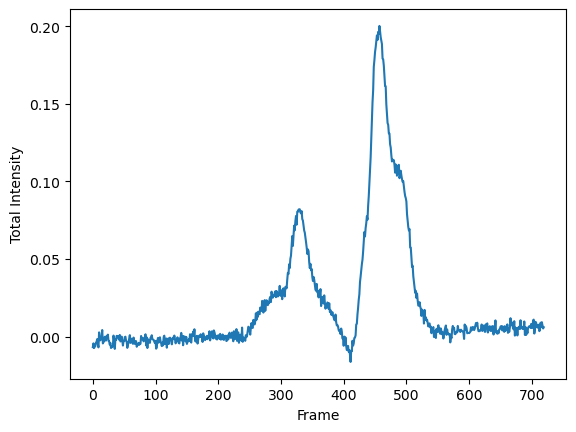

In [8]:
subtracted_total_i = my_series.getIntI('sub')
subtracted_mean_i = my_series.getMeanI('sub')

print(f"Baseline Corrected Series for {series_names[0]}:")
plt.plot(frames, subtracted_total_i, label='subtracted Total I')
plt.xlabel('Frame')
plt.ylabel('Total Intensity')

In [9]:
frames = my_series.getFrames()
total_i = my_series.getIntI()
mean_i = my_series.getMeanI()

subtracted_total_i = my_series.getIntI('sub')
subtracted_mean_i = my_series.getMeanI('sub')


In [10]:
def to_int_scalar(x, fallback=0):
    if x is None:
        return int(fallback)
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.ravel(np.asarray(x))
        if arr.size == 0:
            return int(fallback)
        return int(arr[0])
    try:
        return int(x)
    except Exception:
        return int(fallback)

frames.shape: (720,)
total_i.shape: (720,)


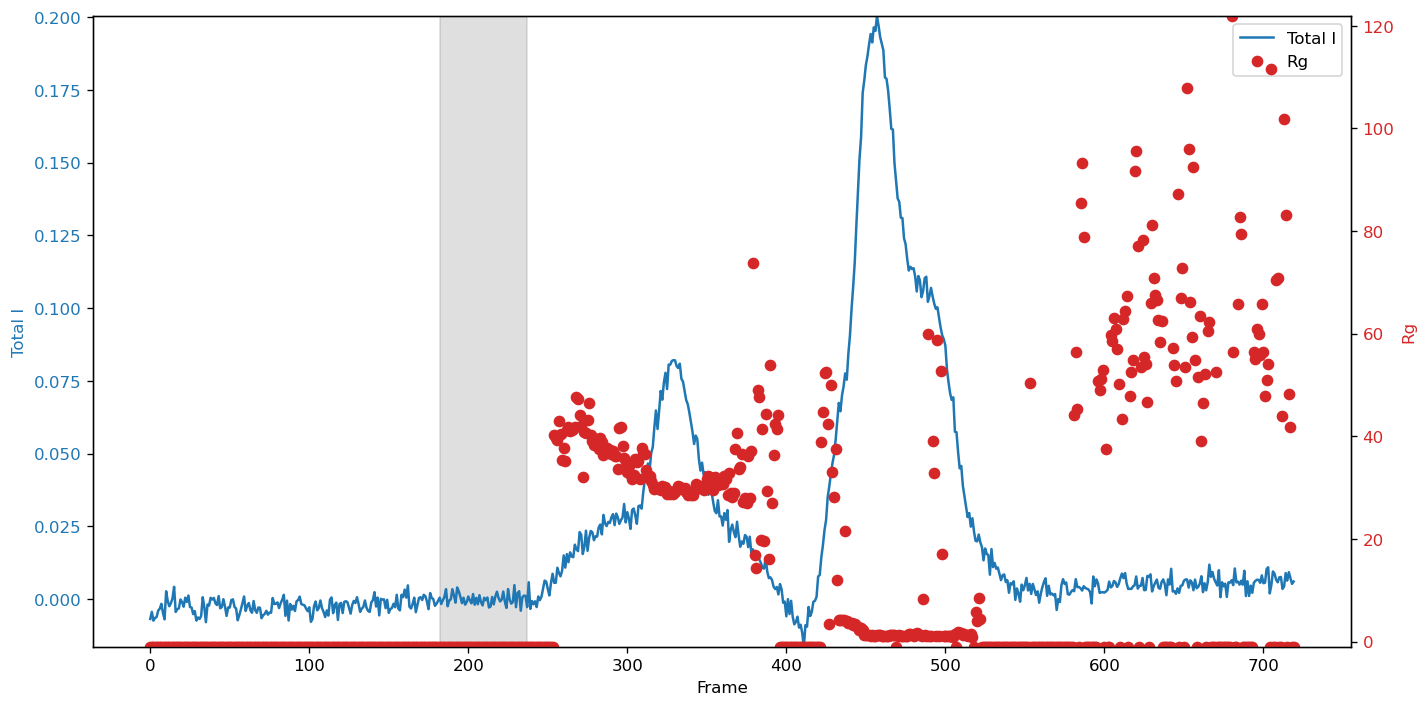

In [11]:
# Plot subtracted_total_i and rg on the same figure with two y-axes, highlighting the buffer region
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=120)

# find background buffer start and end (use defaults if not)
buffer_region_start = to_int_scalar(region_start, 0)
buffer_region_end   = to_int_scalar(region_end, 0)

# lightly translucent rectangle for buffer region (behind the plotted lines)
ax1.axvspan(buffer_region_start, buffer_region_end, color='gray', alpha=0.25, zorder=0)

# Robustly align x (frames) and y (total_i) lengths before plotting
x = frames
y = subtracted_total_i

print("frames.shape:", getattr(x, 'shape', None))
print("total_i.shape:", getattr(y, 'shape', None))

# If total_i is 2D, collapse q axis to produce one scalar per frame
if hasattr(y, 'ndim') and y.ndim == 2:
    # try obvious mappings
    if y.shape[0] == x.shape[0]:
        per_frame = np.sum(y, axis=1)
        x_plot = x
    elif y.shape[1] == x.shape[0]:
        per_frame = np.sum(y, axis=0)
        x_plot = x
    else:
        # fallback: collapse axis 1 and use integer index for x
        per_frame = np.sum(y, axis=1)
        x_plot = np.arange(len(per_frame))
        print("Warning: frames length does not match total_i; plotting per-frame sum vs index.")
else:
    # y is 1D
    if len(y) == len(x):
        per_frame = y
        x_plot = x
    else:
        # fallback: plot y vs its own index
        per_frame = y
        x_plot = np.arange(len(y))
        print("Warning: frames length does not match total_i; plotting total_i vs index.")

c1 = 'tab:blue'
ax1.plot(x_plot, per_frame, color=c1, label='Total I')
ax1.set_xlabel('Frame' if x_plot is frames else 'Index')
ax1.set_ylabel('Total I', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
# set y limits safely ignoring NaNs
try:
    ymin, ymax = np.nanmin(per_frame), np.nanmax(per_frame)
    if ymin == ymax:
        ymin -= 0.5; ymax += 0.5
    ax1.set_ylim(ymin, ymax)
except ValueError:
    pass

ax2 = ax1.twinx()
c2 = 'tab:red'

# Align rg to x_plot if possible, otherwise plot rg vs its own index
rg_arr = np.asarray(rg)
if rg_arr.shape[0] == x_plot.shape[0]:
    ax2.plot(x_plot, rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
else:
    ax2.plot(np.arange(len(rg_arr)), rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
    print("Warning: rg length does not match x used for Total I; plotting rg vs its own index.")

ax2.set_ylabel('Rg', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)
try:
    ymin2, ymax2 = np.nanmin(rg_arr), np.nanmax(rg_arr)
    if ymin2 == ymax2:
        ymin2 -= 0.5; ymax2 += 0.5
    ax2.set_ylim(ymin2, ymax2)
except ValueError:
    pass

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.tight_layout()
plt.show()

### Finding and setting buffer and sample regions



In [12]:
# Baseline Correction
# Validate baseline range
(lin_valid, lin_valid_results, lin_similarity_results, lin_svd_results,
    lin_intI_results, lin_other_results) = raw.validate_baseline_range(
    my_series, [0, 10], [700, 710], 'Linear')

#Do baseline correction
(lin_bl_cor_profiles, lin_rg, lin_rger, lin_i0, lin_i0er, lin_vcmw, lin_vcmwer,
    lin_vpmw, lin_bl_corr, lin_fit_results) = raw.set_baseline_correction(
    my_series, [0, 10], [700, 710], 'Linear')

In [13]:
subtracted_total_i = my_series.getIntI('baseline')
subtracted_mean_i = my_series.getMeanI('baseline')


Baseline Corrected Series for ./data/AA_052024.hdf5:


Text(0, 0.5, 'Total Intensity')

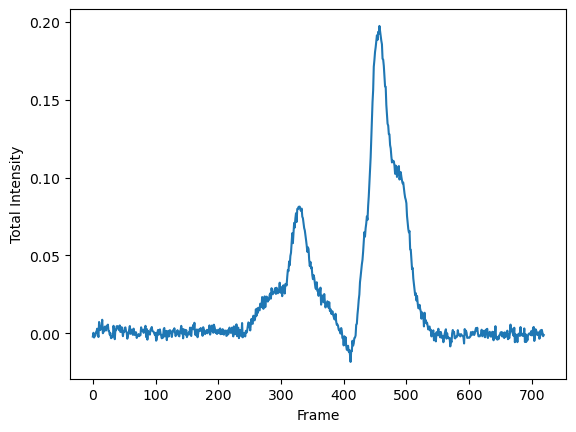

In [14]:
print(f"Baseline Corrected Series for {series_names[0]}:")
plt.plot(frames, subtracted_total_i, label='subtracted Total I')
plt.xlabel('Frame')
plt.ylabel('Total Intensity')

## Back to regular selection

In [15]:
def to_int_scalar(x, fallback=0):
    if x is None:
        return int(fallback)
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.ravel(np.asarray(x))
        if arr.size == 0:
            return int(fallback)
        return int(arr[0])
    try:
        return int(x)
    except Exception:
        return int(fallback)

In [16]:
frames = my_series.getFrames()
total_i = my_series.getIntI()
mean_i = my_series.getMeanI()

subtracted_total_i = my_series.getIntI('baseline')
subtracted_mean_i = my_series.getMeanI('baseline')


frames.shape: (720,)
total_i.shape: (720,)


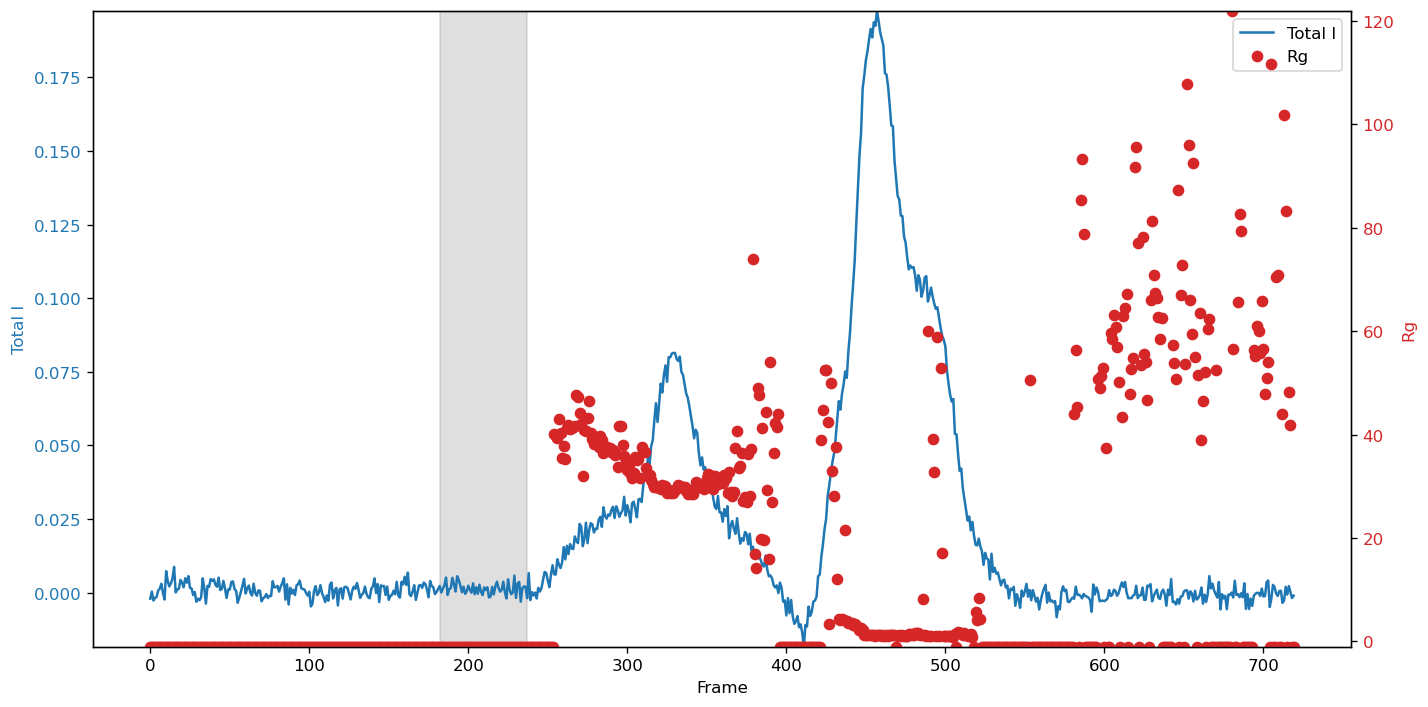

In [17]:
# Plot subtracted_total_i and rg on the same figure with two y-axes, highlighting the buffer region
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=120)

# find background buffer start and end (use defaults if not)
buffer_region_start = to_int_scalar(region_start, 0)
buffer_region_end   = to_int_scalar(region_end, 0)

# lightly translucent rectangle for buffer region (behind the plotted lines)
ax1.axvspan(buffer_region_start, buffer_region_end, color='gray', alpha=0.25, zorder=0)

# Robustly align x (frames) and y (total_i) lengths before plotting
x = frames
y = subtracted_total_i

print("frames.shape:", getattr(x, 'shape', None))
print("total_i.shape:", getattr(y, 'shape', None))

# If total_i is 2D, collapse q axis to produce one scalar per frame
if hasattr(y, 'ndim') and y.ndim == 2:
    # try obvious mappings
    if y.shape[0] == x.shape[0]:
        per_frame = np.sum(y, axis=1)
        x_plot = x
    elif y.shape[1] == x.shape[0]:
        per_frame = np.sum(y, axis=0)
        x_plot = x
    else:
        # fallback: collapse axis 1 and use integer index for x
        per_frame = np.sum(y, axis=1)
        x_plot = np.arange(len(per_frame))
        print("Warning: frames length does not match total_i; plotting per-frame sum vs index.")
else:
    # y is 1D
    if len(y) == len(x):
        per_frame = y
        x_plot = x
    else:
        # fallback: plot y vs its own index
        per_frame = y
        x_plot = np.arange(len(y))
        print("Warning: frames length does not match total_i; plotting total_i vs index.")

c1 = 'tab:blue'
ax1.plot(x_plot, per_frame, color=c1, label='Total I')
ax1.set_xlabel('Frame' if x_plot is frames else 'Index')
ax1.set_ylabel('Total I', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
# set y limits safely ignoring NaNs
try:
    ymin, ymax = np.nanmin(per_frame), np.nanmax(per_frame)
    if ymin == ymax:
        ymin -= 0.5; ymax += 0.5
    ax1.set_ylim(ymin, ymax)
except ValueError:
    pass

ax2 = ax1.twinx()
c2 = 'tab:red'

# Align rg to x_plot if possible, otherwise plot rg vs its own index
rg_arr = np.asarray(rg)
if rg_arr.shape[0] == x_plot.shape[0]:
    ax2.plot(x_plot, rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
else:
    ax2.plot(np.arange(len(rg_arr)), rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
    print("Warning: rg length does not match x used for Total I; plotting rg vs its own index.")

ax2.set_ylabel('Rg', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)
try:
    ymin2, ymax2 = np.nanmin(rg_arr), np.nanmax(rg_arr)
    if ymin2 == ymax2:
        ymin2 -= 0.5; ymax2 += 0.5
    ax2.set_ylim(ymin2, ymax2)
except ValueError:
    pass

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.tight_layout()
plt.show()

## Analyze Region of Interest, Select and Get Profiles

(ROI between 315-360)

### Finding and setting sample regions



In [41]:
# Define a region of interest (ROI) for analysis, zero indexed
roi_start = int(315)
roi_end = int(350)

#Get profiles from the series in a given range, zero indexed
profiles_roi = my_series.getSASMList(roi_start, roi_end)
sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'baseline')


In [29]:
## Zoom in start frame and end frame for analysis
# Zoom into the ROI
start_frame = 200
end_frame = 400

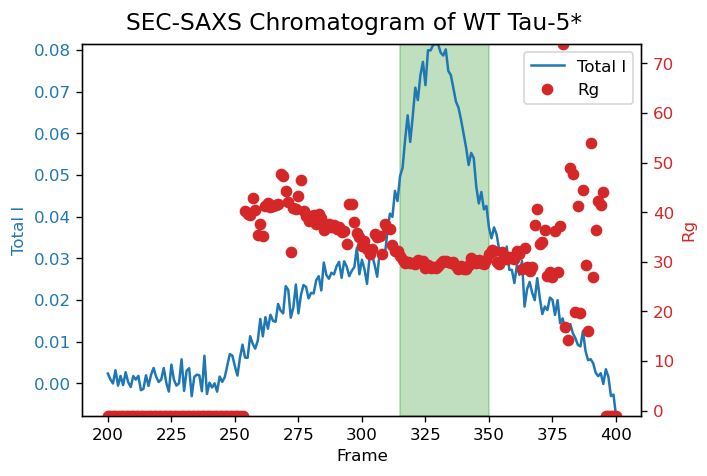

In [30]:
# Plot Total I and Rg with buffer and ROI highlighted, zoomed into the ROI
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

# lightly translucent rectangle for buffer region (behind the plotted lines)
# ax1.axvspan(buffer_region_start, buffer_region_end, color='gray', alpha=0.25, zorder=0)

# lightly translucent rectangle for ROI (behind the plotted lines)
ax1.axvspan(roi_start, roi_end, color='green', alpha=0.25, zorder=0)


# boolean mask to slice arrays
mask = (frames >= start_frame) & (frames <= end_frame)

c1 = 'tab:blue'
ax1.plot(frames[mask], subtracted_total_i[mask], color=c1, label='Total I')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Total I', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
# set y limits safely ignoring NaNs
try:
    ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
    if ymin == ymax:
        ymin -= 0.5; ymax += 0.5
    ax1.set_ylim(ymin, ymax)
except ValueError:
    pass

ax2 = ax1.twinx()
c2 = 'tab:red'
ax2.plot(frames[mask], rg[mask], color=c2, marker='o', linestyle='None', label='Rg')
ax2.set_ylabel('Rg', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)
try:
    ymin2, ymax2 = np.nanmin(rg[mask]), np.nanmax(rg[mask])
    if ymin2 == ymax2:
        ymin2 -= 0.5; ymax2 += 0.5
    ax2.set_ylim(ymin2, ymax2)
except ValueError:
    pass

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.tight_layout(rect=[0, 0, 1, 0.95])            # leave top 8% for title
fig.suptitle(f"SEC-SAXS Chromatogram of WT Tau-5*", fontsize=14)
plt.show()

### Evaluate and Analyze All Profiles between 315-360

In [31]:
# Get the first sub-profile from the ROI
sub_profiles_roi[0]

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_23458/2613774222.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


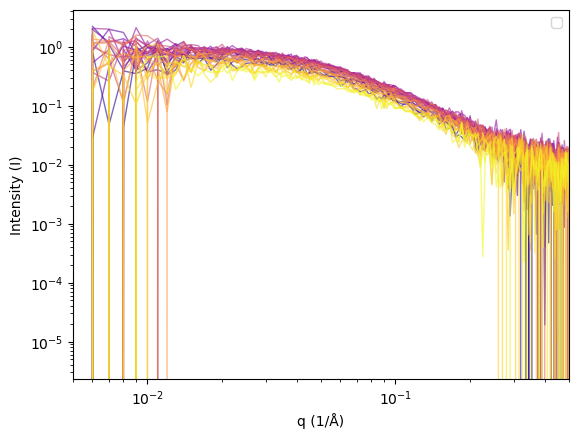

In [32]:
# Plot Sub-profiles
plt.figure()

n = len(sub_profiles_roi)
cmap = plt.cm.plasma  # yellow → purple

for i in range(len(sub_profiles_roi)):
    profile_n = sub_profiles_roi[i]

    q = profile_n.getQ()
    intensity = profile_n.getI()
    error = profile_n.getErr()

    # Normalize index to [0,1] for colormap
    color = cmap(i / (n - 1))

    # Plot individual curves
    plt.plot(q, intensity, color=color, alpha=0.6, linewidth=1)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')
plt.xlim(0.005, 0.5)
plt.legend()


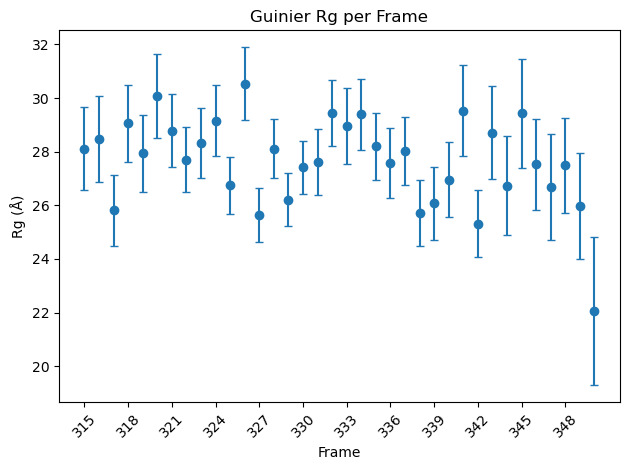

In [33]:
# Plot auto calculated Rg values for each profile in the ROI
# # efficient preallocated collection + nicer x-ticks
n = len(sub_profiles_roi)
rg_values = np.full(n, np.nan, dtype=float)
rg_errors = np.full(n, np.nan, dtype=float)

for j, profile in enumerate(sub_profiles_roi):
    try:
        rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max, r_sq = \
            raw.auto_guinier(profile, settings=my_settings)
        rg_values[j] = rg_j
        rg_errors[j] = rg_err_j
    except Exception as e:
        # keep NaN for failed fit, print brief info
        print(f"Guinier failed for ROI frame {j} (global frame {to_int_scalar(roi_start)+j}): {e}")

# map to real frame numbers
roi_start_val = to_int_scalar(roi_start)
frame_numbers = roi_start_val + np.arange(n)

fig, ax = plt.subplots()
rg_errors = np.abs(rg_errors)  # ensure non-negative errors for plotting
ax.errorbar(frame_numbers, rg_values, yerr=rg_errors, fmt='o', capsize=3)
ax.set_xlabel('Frame')
ax.set_ylabel('Rg (Å)')
ax.set_title('Guinier Rg per Frame')

# sensible x-ticks: show all for small ROI, subsample for larger
if n <= 20:
    ticks = frame_numbers
else:
    step = max(1, n // 10)
    ticks = frame_numbers[::step]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45)

fig.tight_layout()
plt.show()
# ...existing code...

[28.11395884 28.48082308 25.81463636 29.05531777 27.93753404 30.08488706
 28.77157364 27.7072742  28.31566873 29.16236658 26.74840719 30.54166356
 25.64228301 28.10756325 26.20627815 27.4219854  27.61000155 29.44020502
 28.95327106 29.40003474 28.20462376 27.57753497 28.03428562 25.71241533
 26.06967144 26.94839555 29.53076133 25.31000903 28.71128543 26.73555932
 29.42432613 27.5236428  26.67717937 27.493175   25.96326282 22.0492975 ]


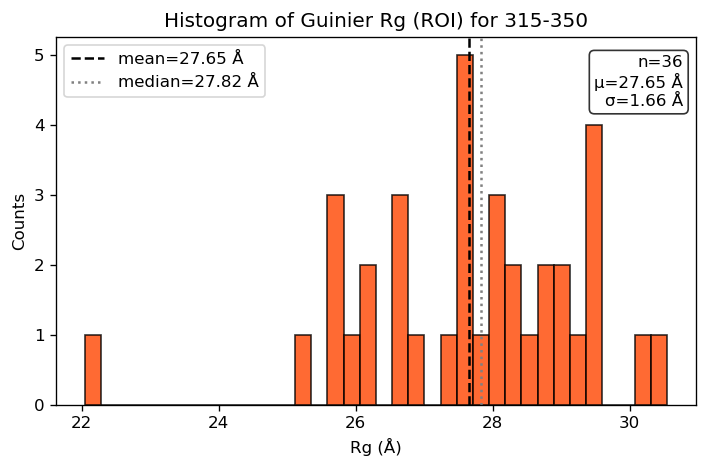

In [34]:
# Plot auto calculated Rg values for each profile in the ROI
# # efficient preallocated collection + nicer x-ticks
n = len(sub_profiles_roi)
rg_values = np.full(n, np.nan, dtype=float)
rg_errors = np.full(n, np.nan, dtype=float)

for j, profile in enumerate(sub_profiles_roi):
    try:
        rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max, r_sq = \
            raw.auto_guinier(profile, settings=my_settings)
        rg_values[j] = rg_j
        rg_errors[j] = rg_err_j
    except Exception as e:
        # keep NaN for failed fit, print brief info
        print(f"Guinier failed for ROI frame {j} (global frame {to_int_scalar(roi_start)+j}): {e}")

print(rg_values)

# Plot Rg values in histogram
fig.tight_layout()
plt.show()

# histogram of Rg values (ignore NaNs)
valid = ~np.isnan(rg_values)
if np.count_nonzero(valid) == 0:
    print("No valid Rg values to plot.")
else:
    vals = rg_values[valid]
    mean_rg = np.mean(vals)
    median_rg = np.median(vals)
    std_rg = np.std(vals, ddof=1)

    plt.figure(figsize=(6,4), dpi=120)
    plt.hist(vals, bins=n, color=colorAA, alpha=0.8, edgecolor='k')
    plt.axvline(mean_rg, color='black', linestyle='--', label=f'mean={mean_rg:.2f} Å')
    plt.axvline(median_rg, color='gray', linestyle=':', label=f'median={median_rg:.2f} Å')
    plt.xlabel('Rg (Å)')
    plt.ylabel('Counts')
    plt.title(f"Histogram of Guinier Rg (ROI) for {roi_start}-{roi_end}")
    plt.legend(loc='best')
    plt.gca().text(0.98, 0.95, f'n={len(vals)}\nμ={mean_rg:.2f} Å\nσ={std_rg:.2f} Å',
                   transform=plt.gca().transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()
# ...existing code...

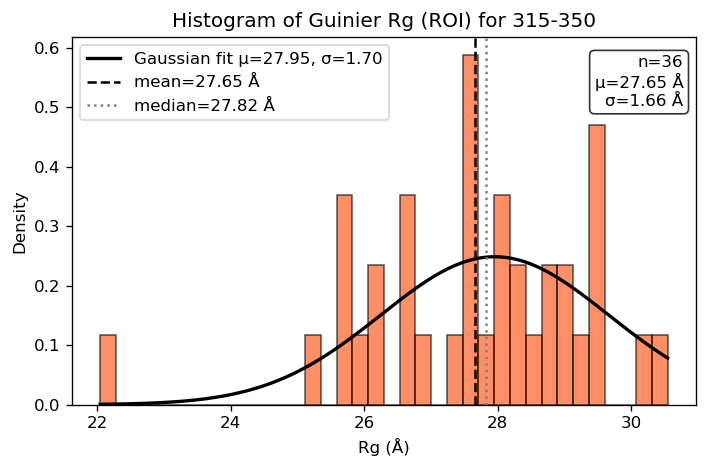

In [35]:
# Plot auto calculated Rg values for each profile in the ROI
# # efficient preallocated collection + nicer x-ticks
n = len(sub_profiles_roi)
rg_values = np.full(n, np.nan, dtype=float)
rg_errors = np.full(n, np.nan, dtype=float)

for j, profile in enumerate(sub_profiles_roi):
    try:
        rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max, r_sq = \
            raw.auto_guinier(profile, settings=my_settings)
        rg_values[j] = rg_j
        rg_errors[j] = rg_err_j
    except Exception as e:
        # keep NaN for failed fit, print brief info
        print(f"Guinier failed for ROI frame {j} (global frame {to_int_scalar(roi_start)+j}): {e}")

# Plot Rg values in histogram
fig.tight_layout()
plt.show()

# histogram of Rg values (ignore NaNs)
valid = ~np.isnan(rg_values)
if np.count_nonzero(valid) == 0:
    print("No valid Rg values to plot.")
else:
    vals = rg_values[valid]
    mean_rg = np.mean(vals)
    median_rg = np.median(vals)
    std_rg = np.std(vals, ddof=1)

    # control bin count here
    nbins = n

    plt.figure(figsize=(6,4), dpi=120)
    # plot density histogram so fitted PDF overlays correctly
    counts, bins, patches = plt.hist(vals, bins=nbins, density=True,
                                     color=colorAA, alpha=0.6, edgecolor='k')

    # bin centers for fitting / diagnostics
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Try to fit a Gaussian with scipy.optimize.curve_fit
    try:
        from scipy.optimize import curve_fit

        def gauss(x, A, mu, sigma):
            return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

        p0 = [1.0, mean_rg, std_rg]
        popt, pcov = curve_fit(gauss, bin_centers, counts, p0=p0)
        x = np.linspace(bins[0], bins[-1], 400)
        plt.plot(x, gauss(x, *popt), color='black', lw=2,
                 label=f'Gaussian fit μ={popt[1]:.2f}, σ={popt[2]:.2f}')
    except Exception:
        # fallback to KDE if curve_fit / scipy not available
        try:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(vals)
            x = np.linspace(bins[0], bins[-1], 400)
            plt.plot(x, kde(x), color='black', lw=2, label='KDE')
        except Exception:
            # final fallback: plot normal pdf using sample mean/std
            x = np.linspace(bins[0], bins[-1], 400)
            pdf = (1 / (std_rg * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_rg) / std_rg) ** 2)
            plt.plot(x, pdf, color='black', lw=2, label=f'Normal μ={mean_rg:.2f}, σ={std_rg:.2f}')

    # annotate vertical lines and text
    plt.axvline(mean_rg, color='black', linestyle='--', label=f'mean={mean_rg:.2f} Å')
    plt.axvline(median_rg, color='gray', linestyle=':', label=f'median={median_rg:.2f} Å')

    plt.xlabel('Rg (Å)')
    plt.ylabel('Density')
    plt.title(f"Histogram of Guinier Rg (ROI) for {roi_start}-{roi_end}")
    plt.legend(loc='best')
    plt.gca().text(0.98, 0.95, f'n={len(vals)}\nμ={mean_rg:.2f} Å\nσ={std_rg:.2f} Å',
                   transform=plt.gca().transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()

In [36]:
# # IF YOU WANT TO SAVE THE PROFILES IN THE ROI TO INDIVIDUAL .DAT FILES, UNCOMMENT THE FOLLOWING CODE BLOCK AND SET THE OUTPUT DIRECTORY
# # save profiles in the ROI to individual .dat files
# output_dir = './dat_files/'

# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# for i, profile in enumerate(sub_profiles_roi):
#     raw.save_profile(profile, os.path.join(output_dir, f'profile_{roi_start + i}.dat'))


### Moving window of subprofiles

Center frame for step-wise analysis: 332 for 315:350
Processing window j=1: frames 331 to 333


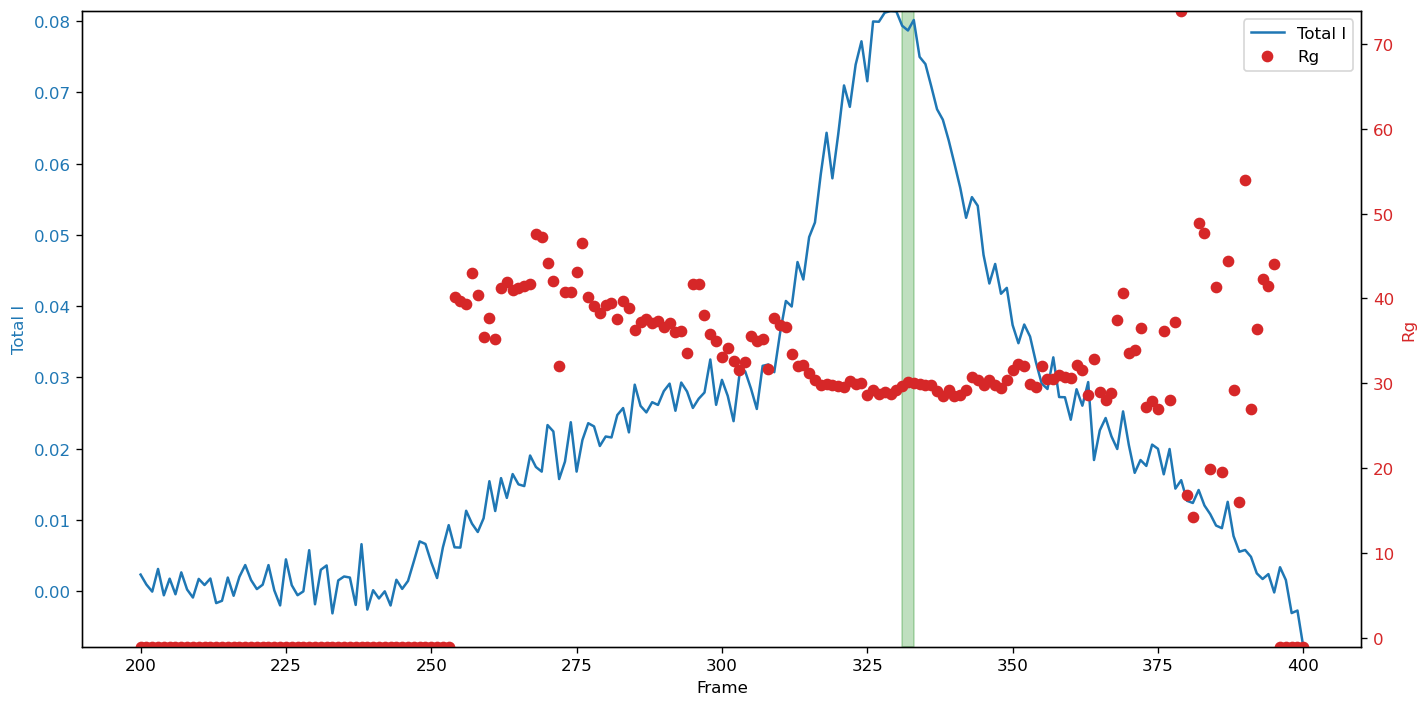

Processing window j=2: frames 330 to 334


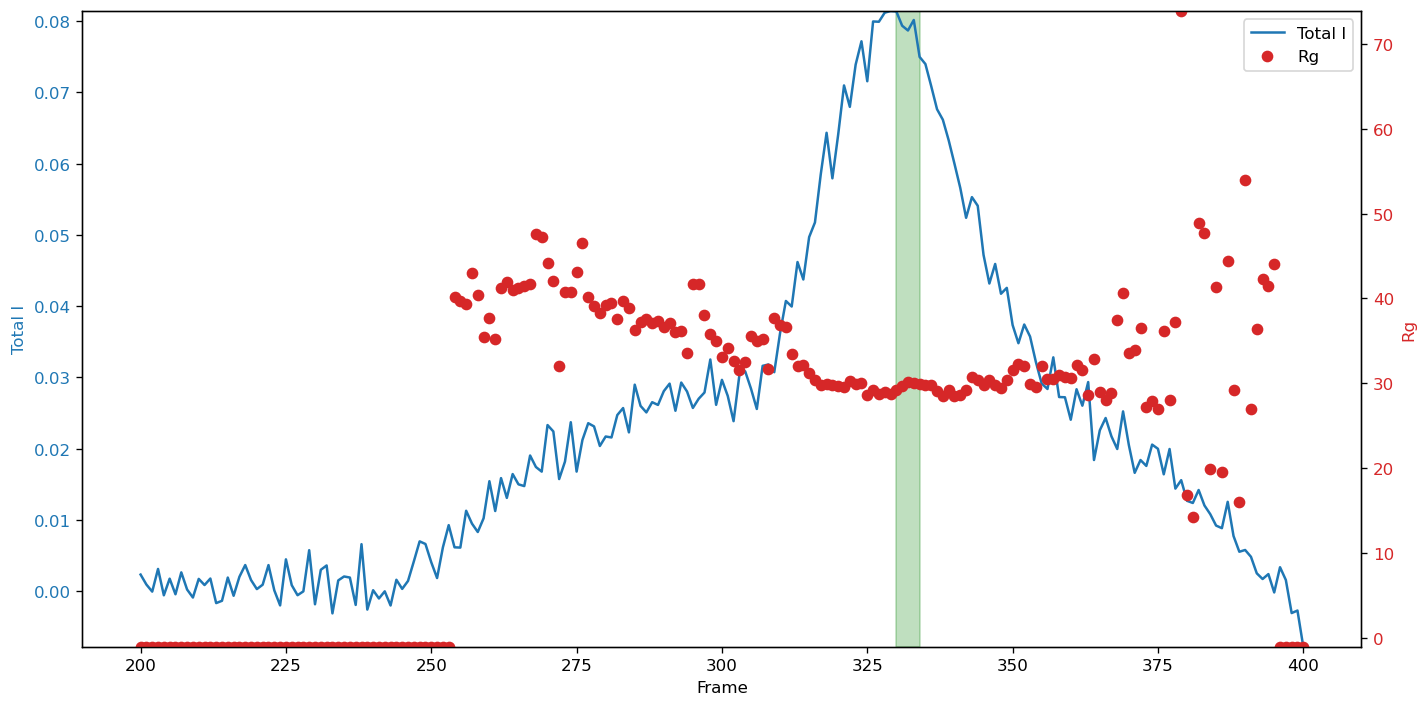

Processing window j=3: frames 329 to 335


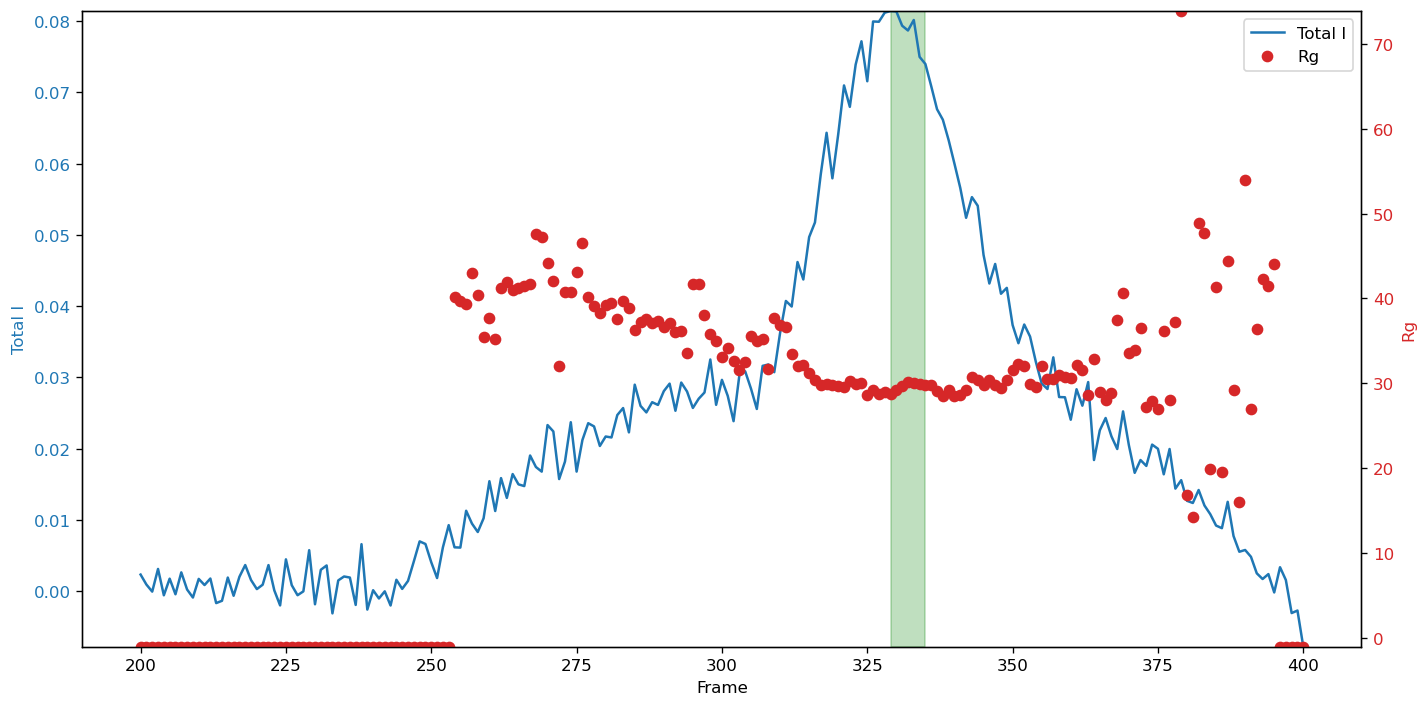

Processing window j=4: frames 328 to 336


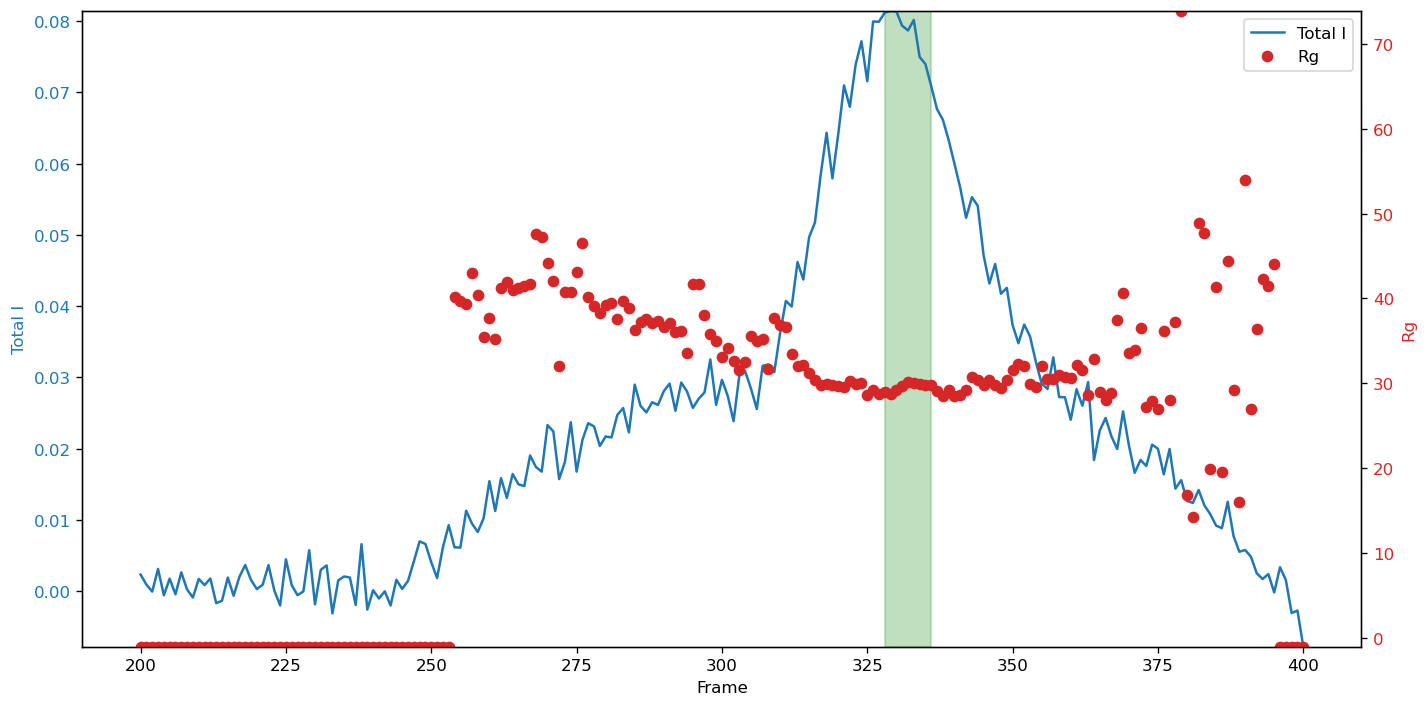

Processing window j=5: frames 327 to 337


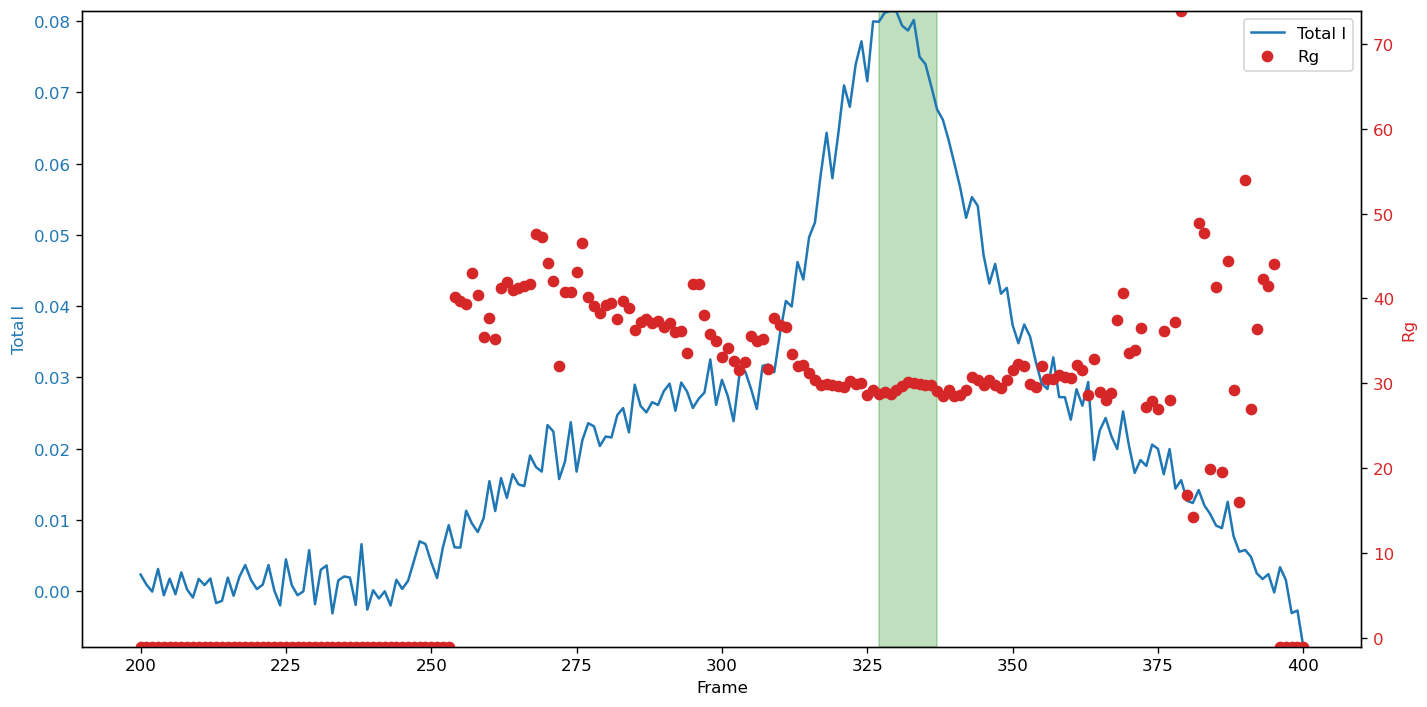

Processing window j=6: frames 326 to 338


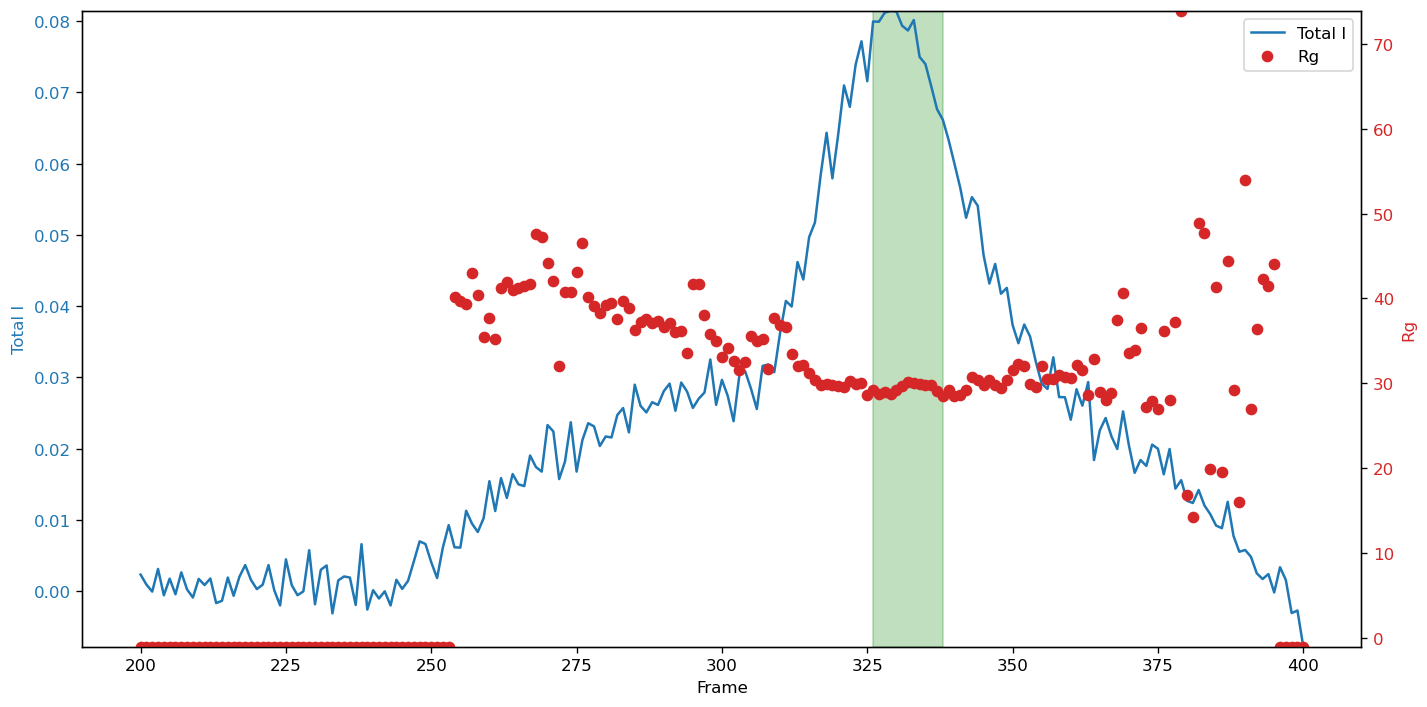

Processing window j=7: frames 325 to 339


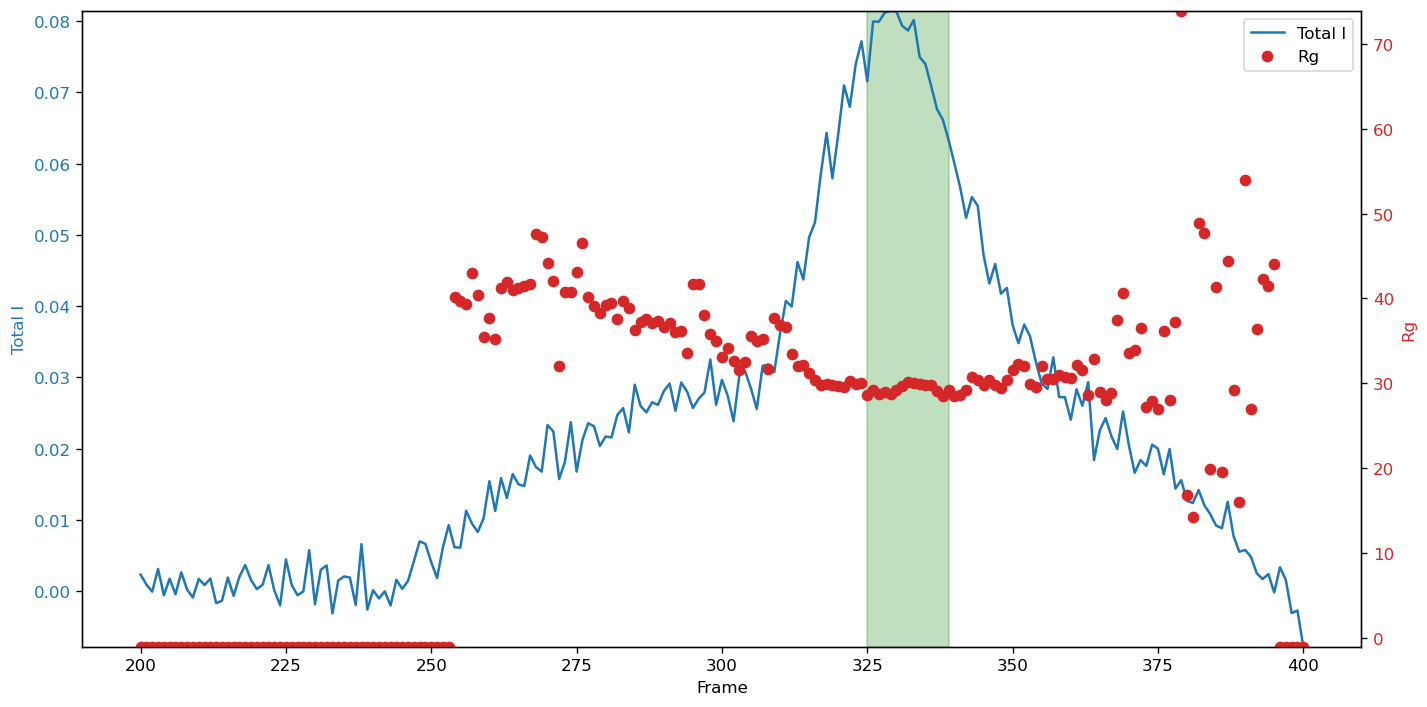

Processing window j=8: frames 324 to 340


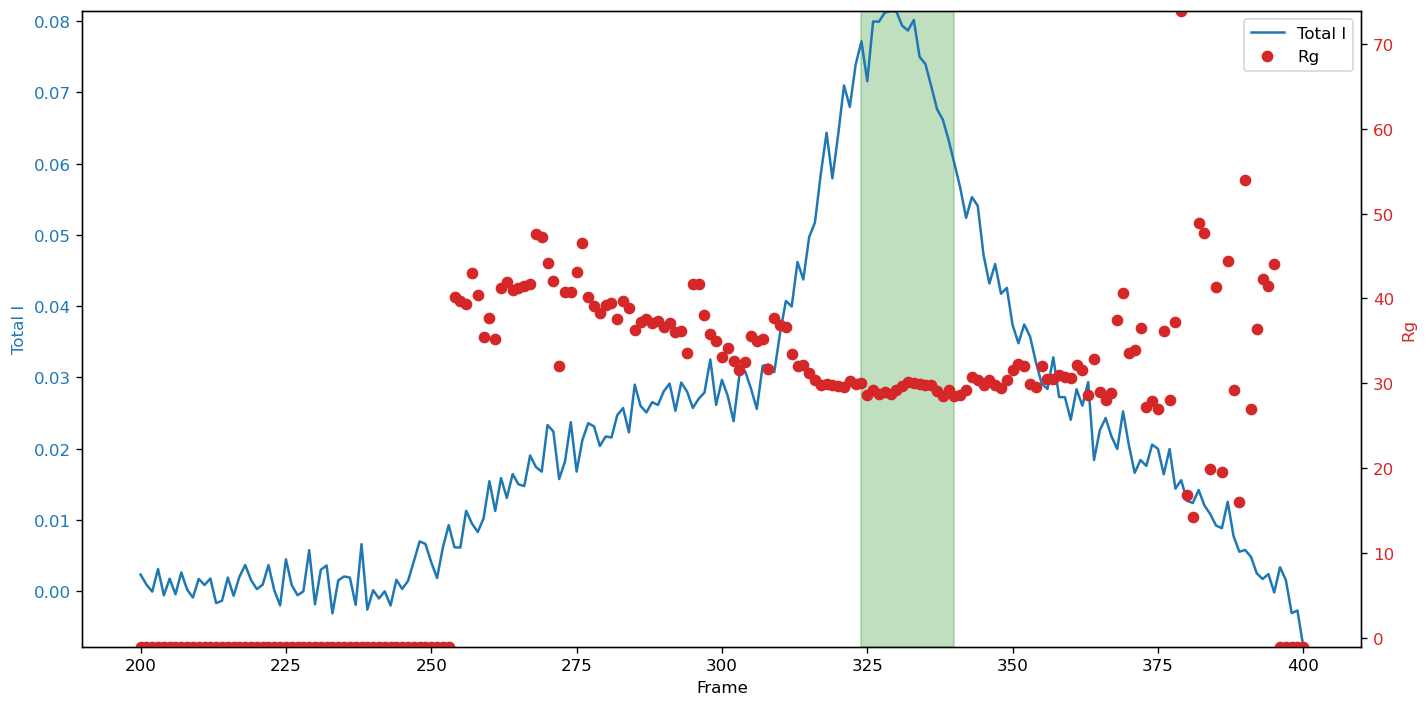

Processing window j=9: frames 323 to 341


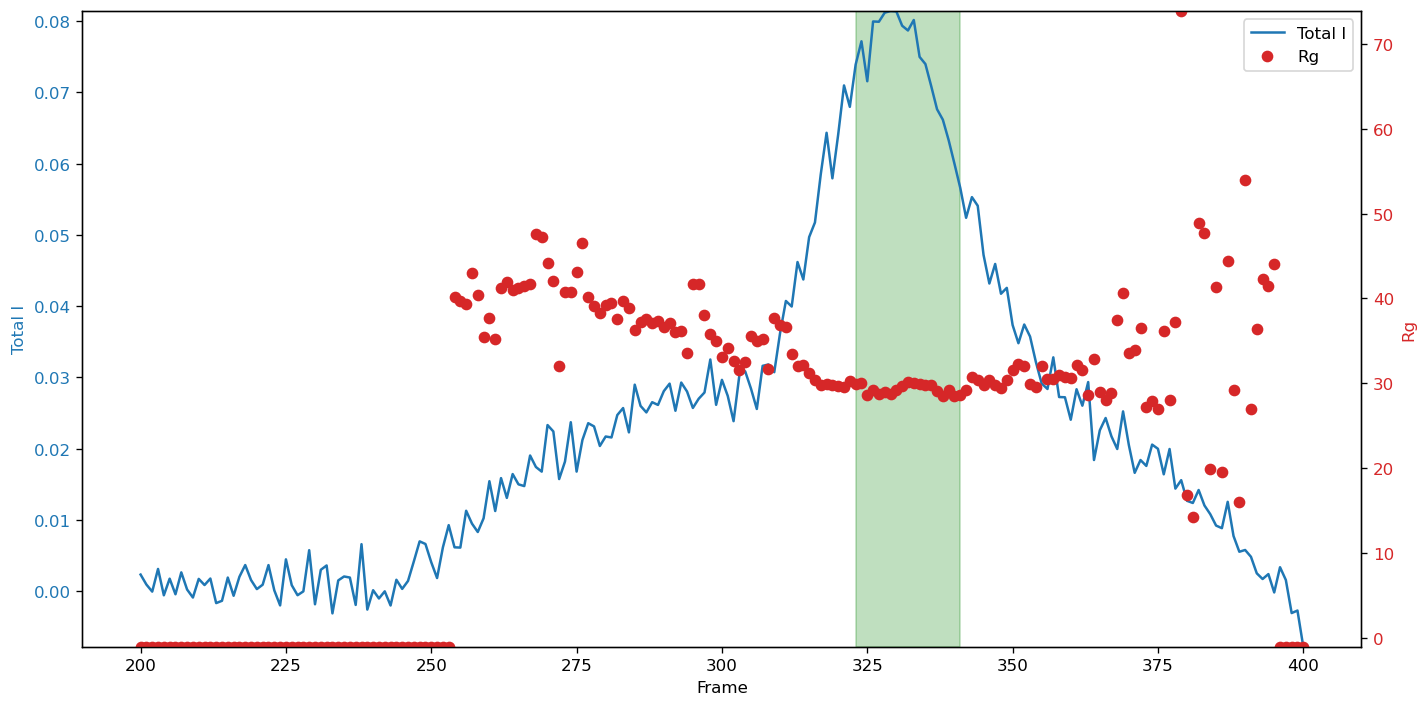

Processing window j=10: frames 322 to 342


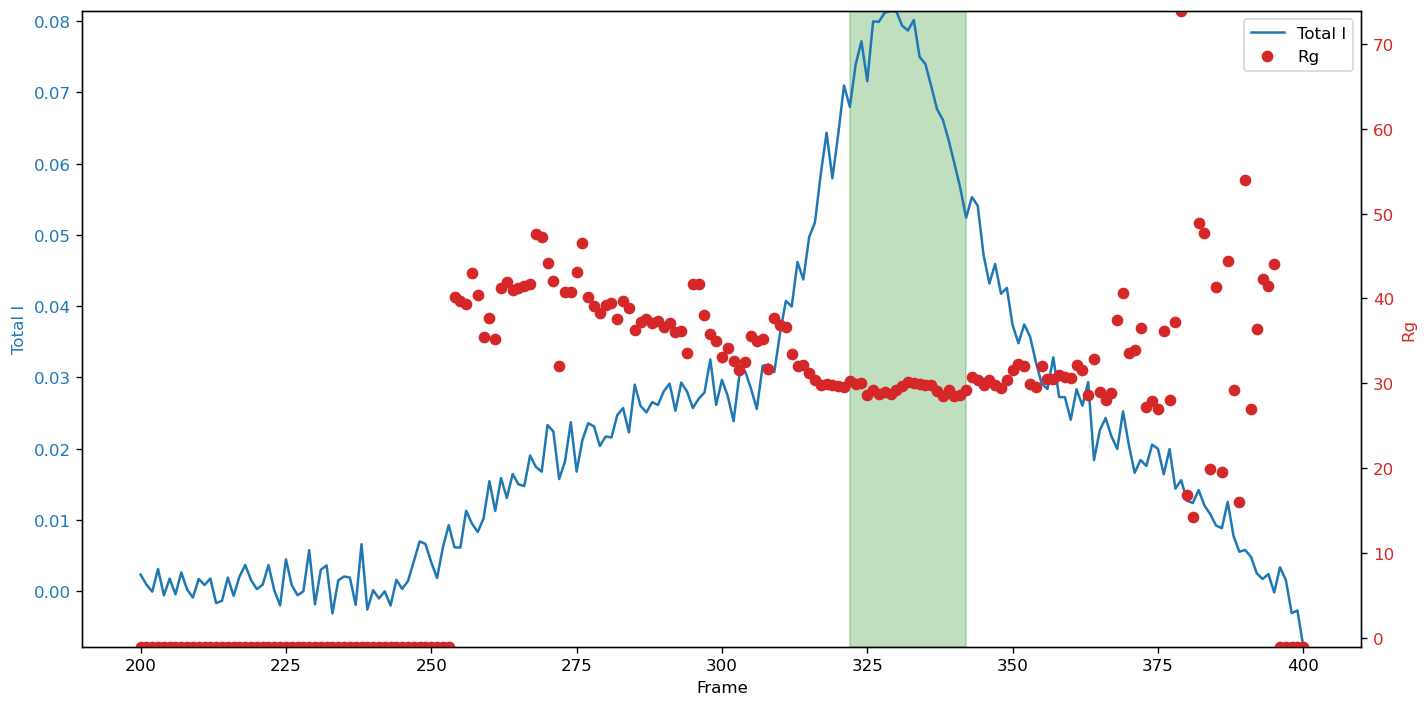

Processing window j=11: frames 321 to 343


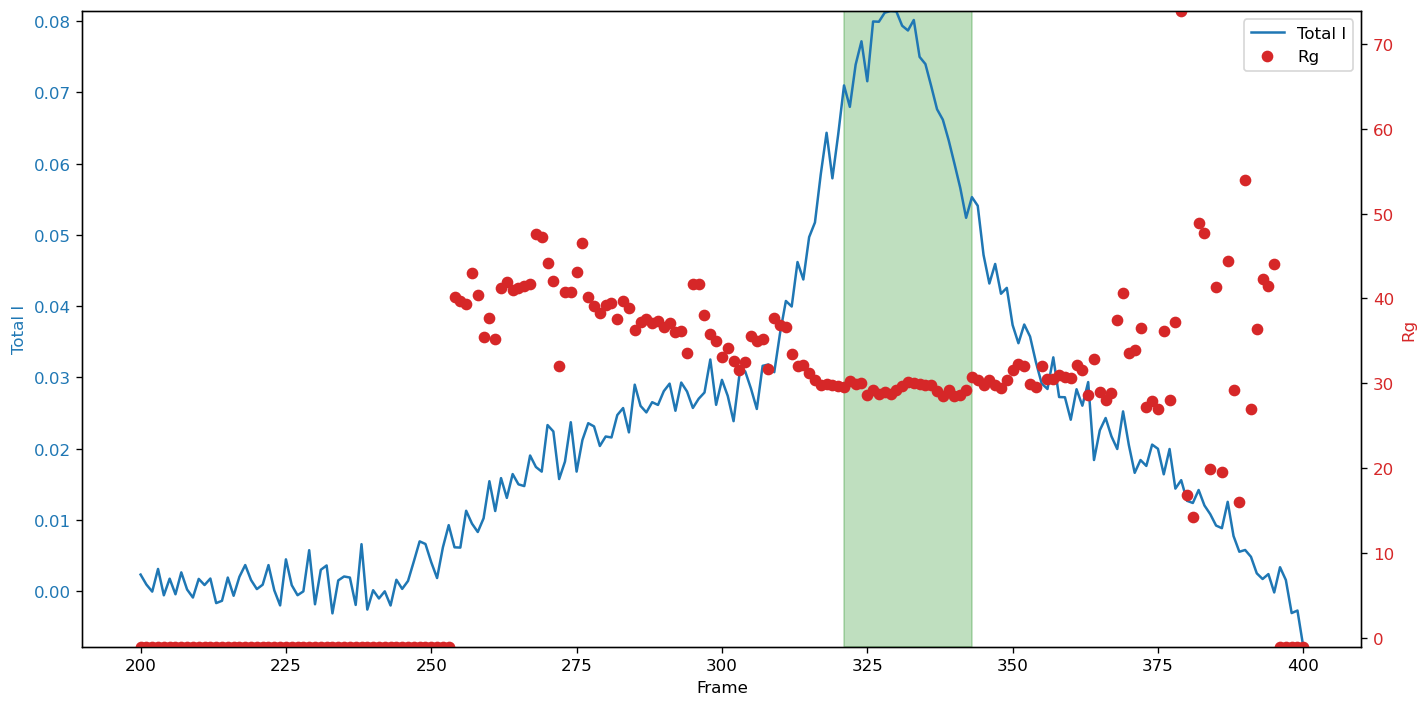

Processing window j=12: frames 320 to 344


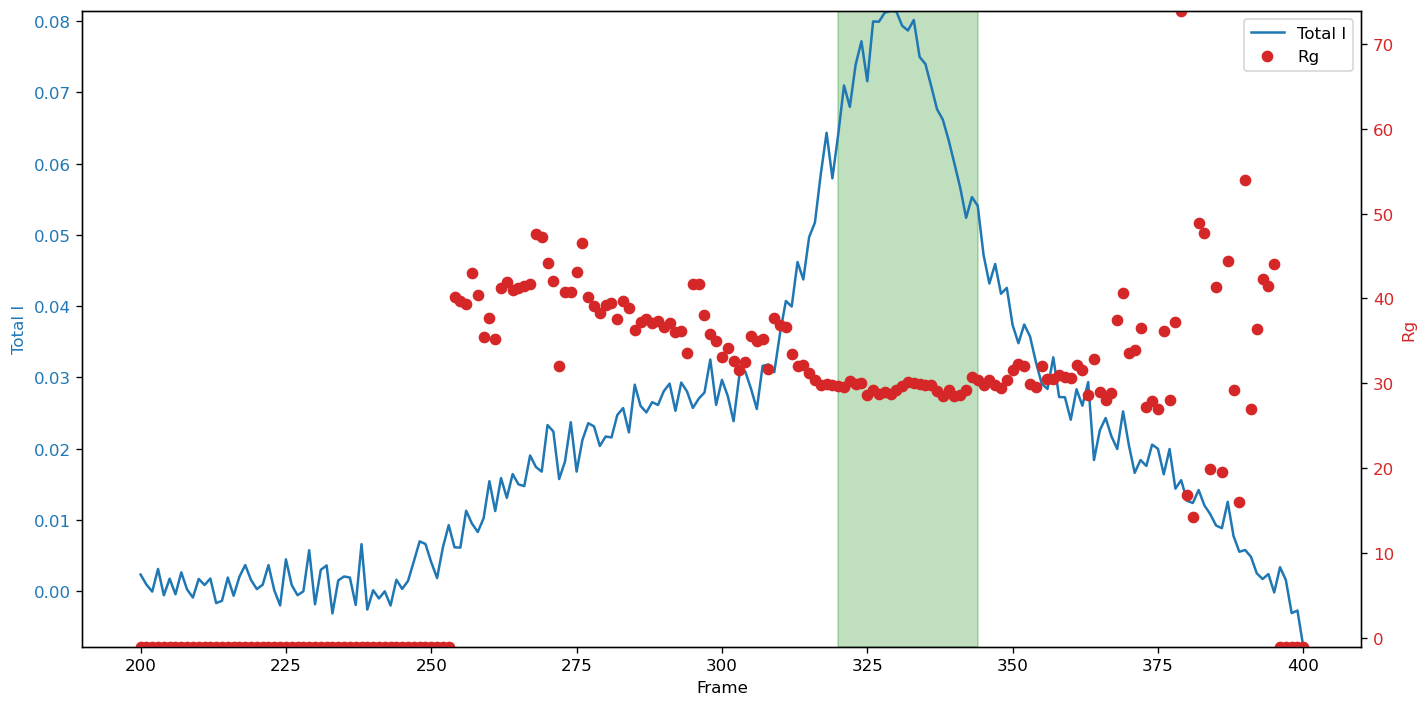

Processing window j=13: frames 319 to 345


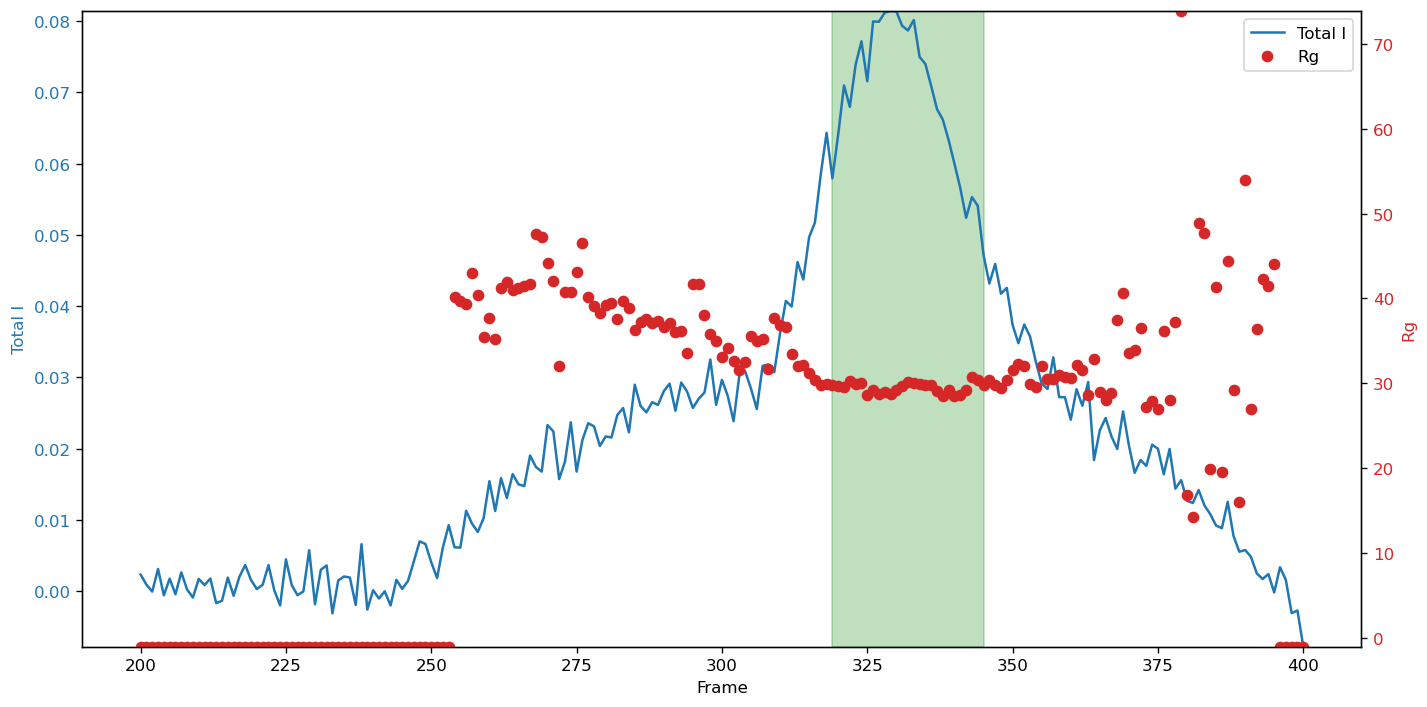

Processing window j=14: frames 318 to 346


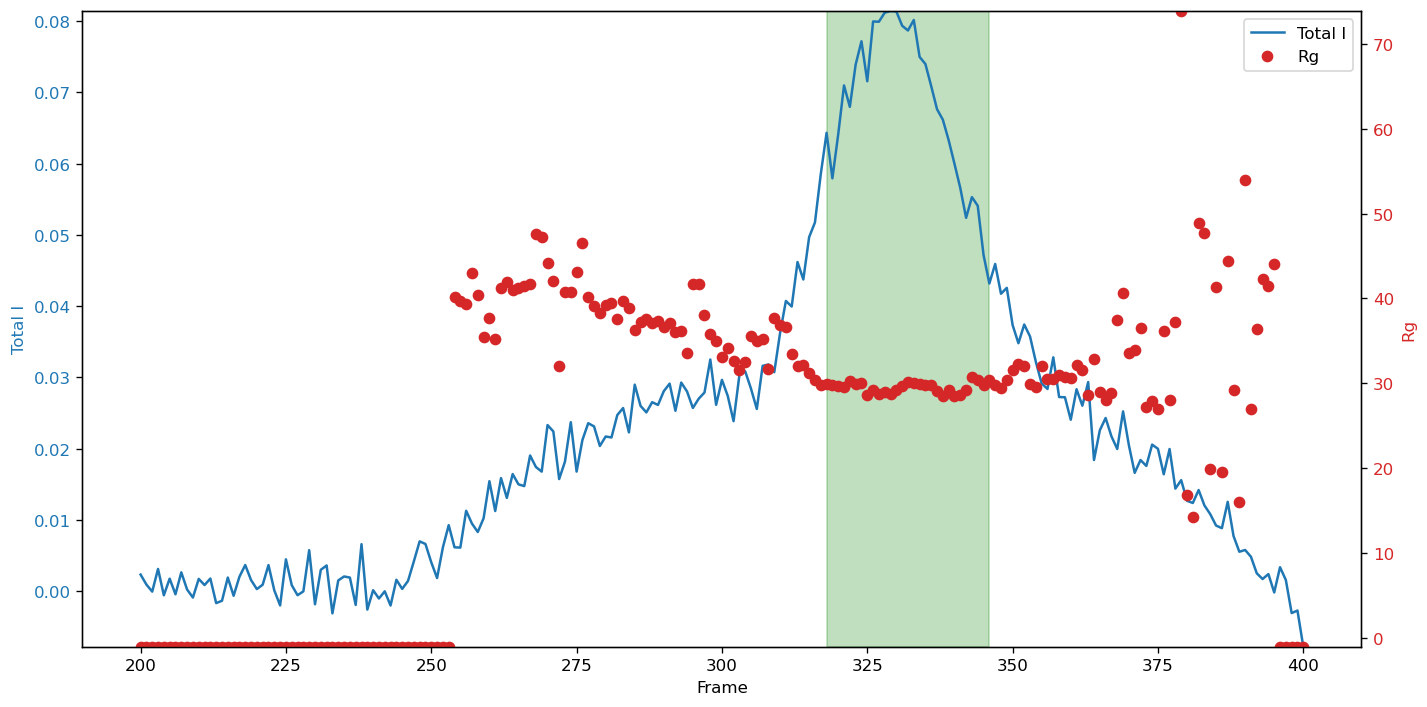

Processing window j=15: frames 317 to 347


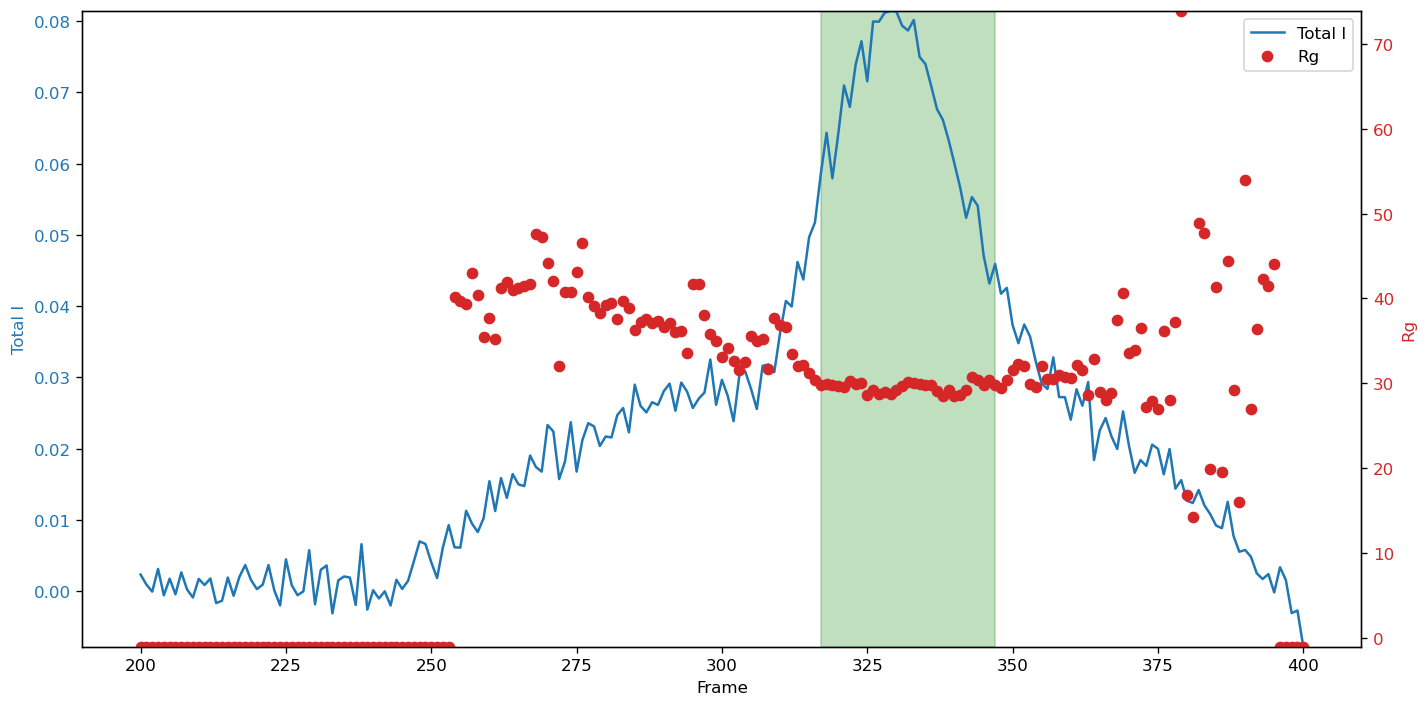

Processing window j=16: frames 316 to 348


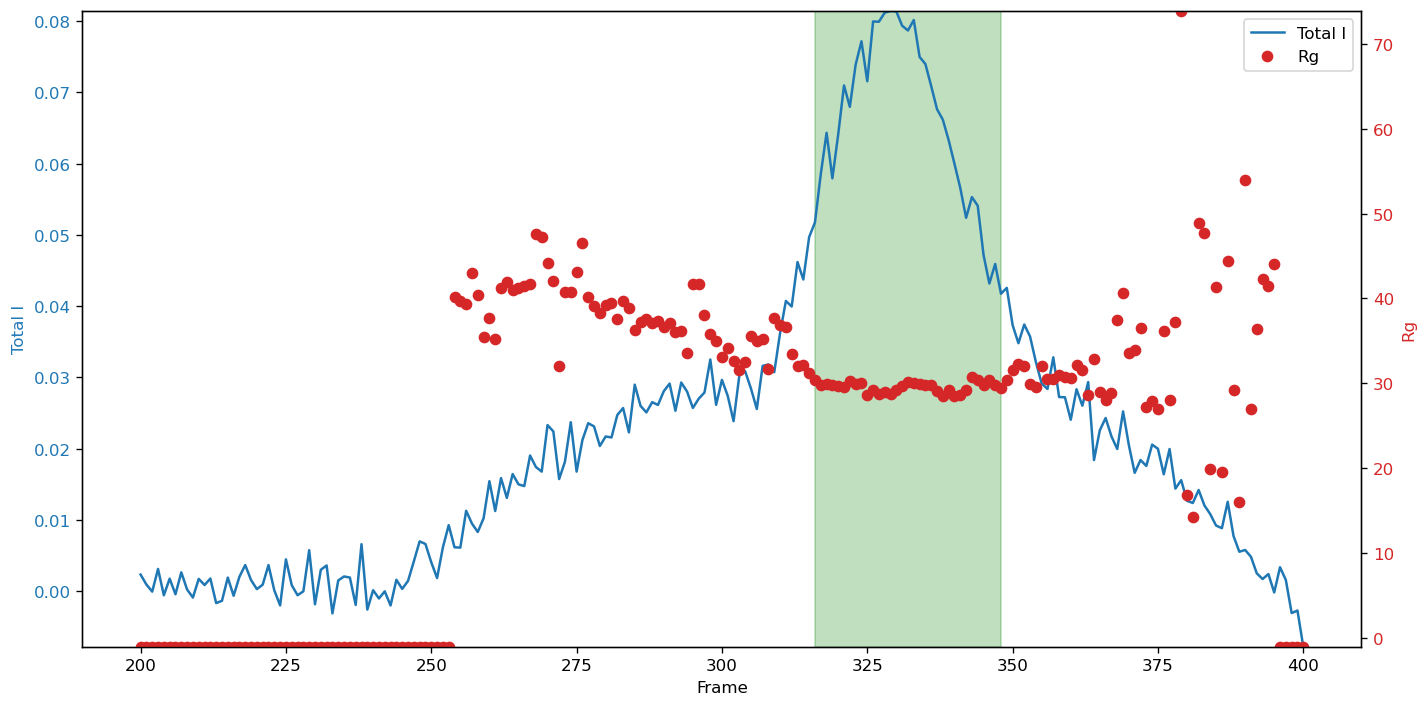

Processing window j=17: frames 315 to 349


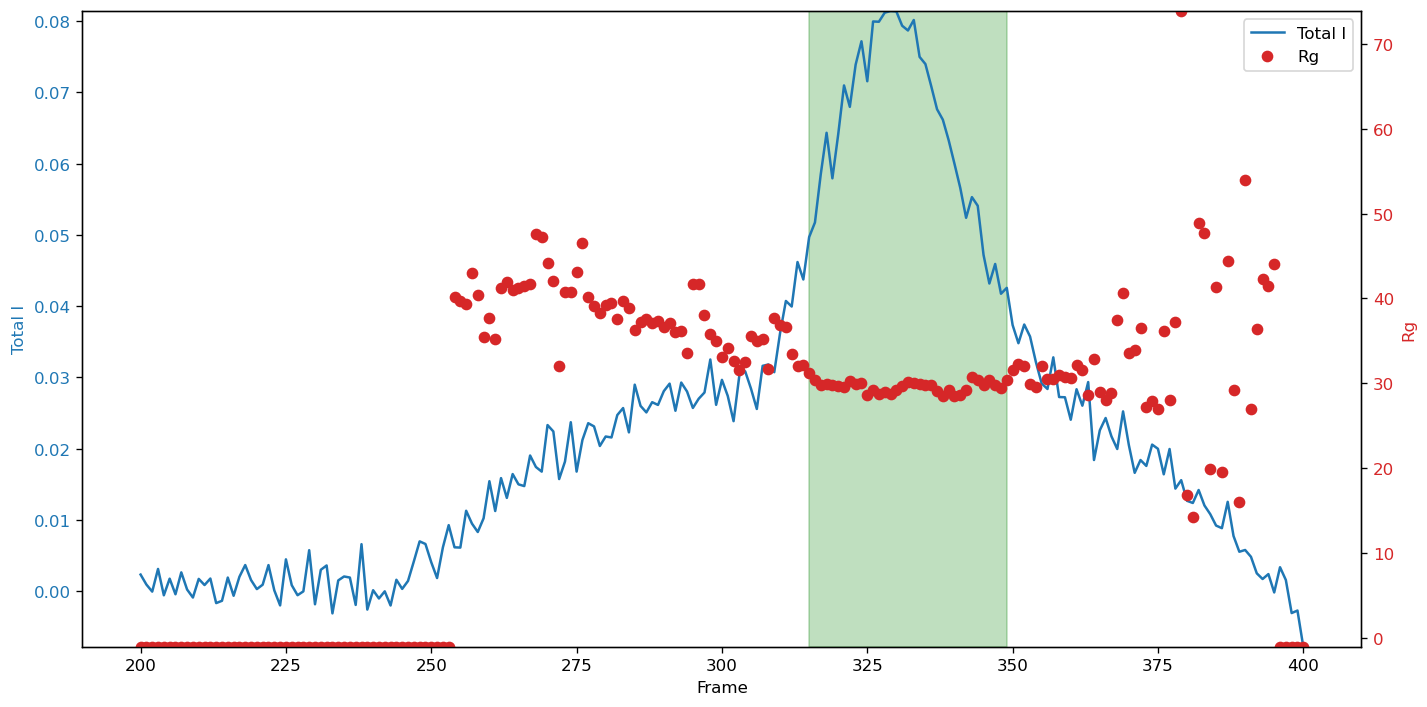

Processing window j=18: frames 314 to 350


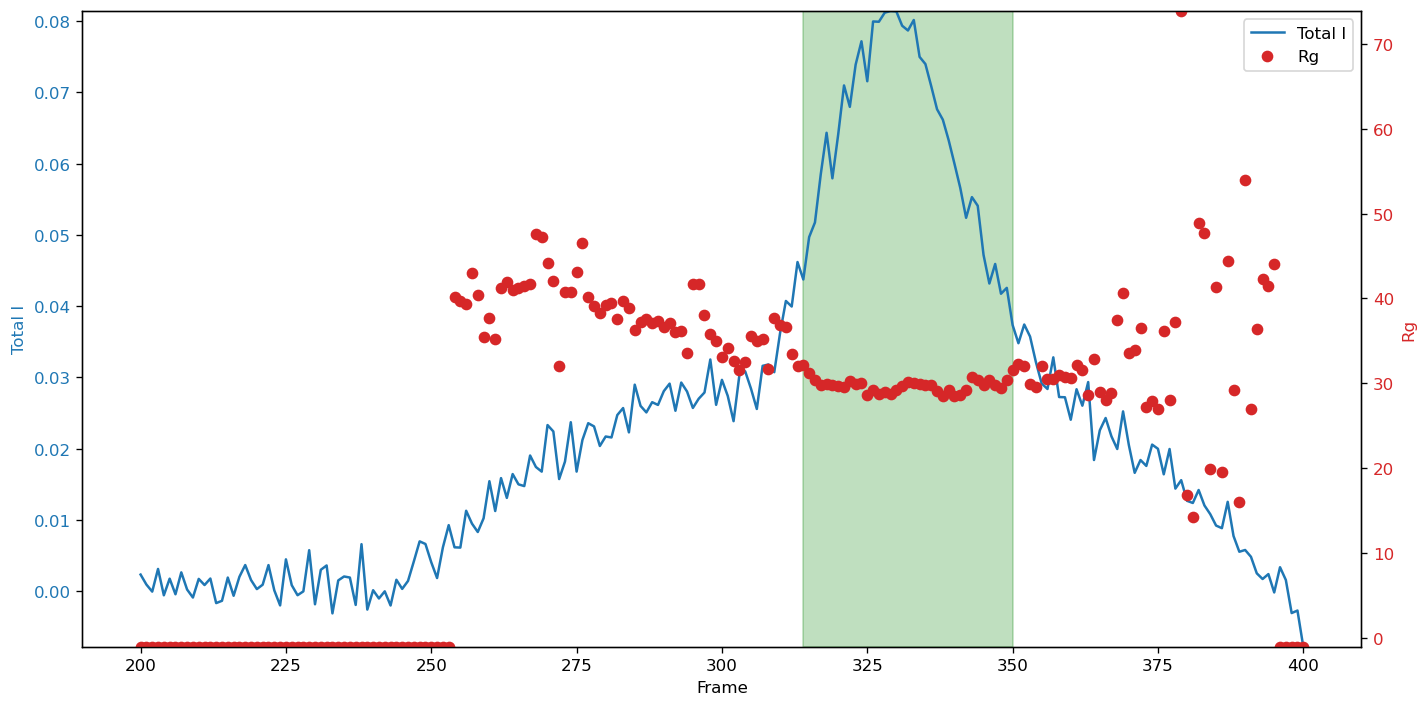

steps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
rg_values: [29.88136521 30.21207615 29.87709171 29.45480135 29.35304432 29.49028836
 29.25148024 29.49290064 29.49065302 29.35917167 29.49577723 29.72759612
 29.74555879 29.75809878 29.53783408 29.67182798 29.66692819 29.73221947]
rg_errors: [0.75596338 0.62028412 0.4946135  0.44442353 0.4054106  0.37361783
 0.30987421 0.33379059 0.31811431 0.28761029 0.29650973 0.30742296
 0.29982948 0.29320357 0.26920856 0.28382982 0.28016526 0.27658063]


In [42]:
centerframe=int(roi_start + ((roi_end - roi_start)/2))
print(f"Center frame for step-wise analysis: {centerframe} for {roi_start}:{roi_end}")

# step-wise j values: 1,3,5,...,13
steps = list(range(1, 19, 1))
m = len(steps)

rg_values = np.full(m, np.nan, dtype=float)
rg_errors = np.full(m, np.nan, dtype=float)
x_labels = []

for k, j in enumerate(steps):
    roi_start = int(centerframe - j)
    roi_end = int(centerframe + j)  # +1 to include centerframe+j in the slice
    print(f"Processing window j={j}: frames {roi_start} to {roi_end}")
    x_labels.append(f"{roi_start}:{roi_end}")

    sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')
    # Plot Total I and Rg with buffer and ROI highlighted, zoomed into the ROI
    fig, ax1 = plt.subplots(figsize=(12, 6), dpi=120)

    # lightly translucent rectangle for ROI (behind the plotted lines)
    ax1.axvspan(roi_start, roi_end, color='green', alpha=0.25, zorder=0)



    # boolean mask to slice arrays
    mask = (frames >= start_frame) & (frames <= end_frame)

    c1 = 'tab:blue'
    ax1.plot(frames[mask], subtracted_total_i[mask], color=c1, label='Total I')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Total I', color=c1)
    ax1.tick_params(axis='y', labelcolor=c1)
    # set y limits safely ignoring NaNs
    try:
        ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
        if ymin == ymax:
            ymin -= 0.5; ymax += 0.5
        ax1.set_ylim(ymin, ymax)
    except ValueError:
        pass

    ax2 = ax1.twinx()
    c2 = 'tab:red'
    ax2.plot(frames[mask], rg[mask], color=c2, marker='o', linestyle='None', label='Rg')
    ax2.set_ylabel('Rg', color=c2)
    ax2.tick_params(axis='y', labelcolor=c2)
    try:
        ymin2, ymax2 = np.nanmin(rg[mask]), np.nanmax(rg[mask])
        if ymin2 == ymax2:
            ymin2 -= 0.5; ymax2 += 0.5
        ax2.set_ylim(ymin2, ymax2)
    except ValueError:
        pass

    # combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

    fig.tight_layout()
    plt.show()
    average_profile = raw.average(sub_profiles_roi)
    try:
        (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
         idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
        rg_values[k] = rg_j
        rg_errors[k] = rg_err_j
    except Exception as e:
        print(f"Error processing window j={j} (slice {roi_start}:{end}): {e}")

print("steps:", steps)
print("rg_values:", rg_values)
print("rg_errors:", rg_errors)
# ...existing code...

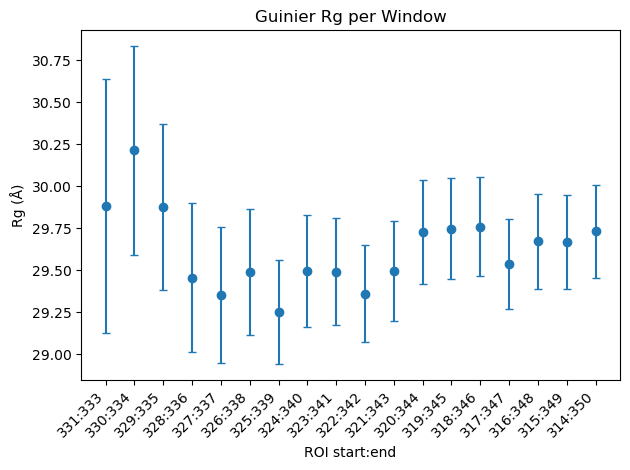

In [43]:
# make numeric x positions and use x_labels for tick labels
x = np.arange(len(x_labels))                     # numeric positions 0..N-1
fig, ax = plt.subplots()
ax.errorbar(x, rg_values, yerr=rg_errors, fmt='o', capsize=3)
ax.set_xlabel('ROI start:end')
ax.set_ylabel('Rg (Å)')
ax.set_title('Guinier Rg per Window')

m = len(x_labels)
# choose which tick positions to show (all for small m, subsample for large)
if m <= 20:
    ticks = x
else:
    step = max(1, m // 10)
    ticks = x[::step]

ax.set_xticks(ticks)
ax.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')

fig.tight_layout()
plt.show()

In [44]:
# Define a LARGE region of interest (ROI) for analysis with centerframe and step range
range_int =int(30)
centerframe_int= int(roi_start)
step_range_int = int(20)

rg_lower_limit = int(15)
rg_upper_limit = int(40)

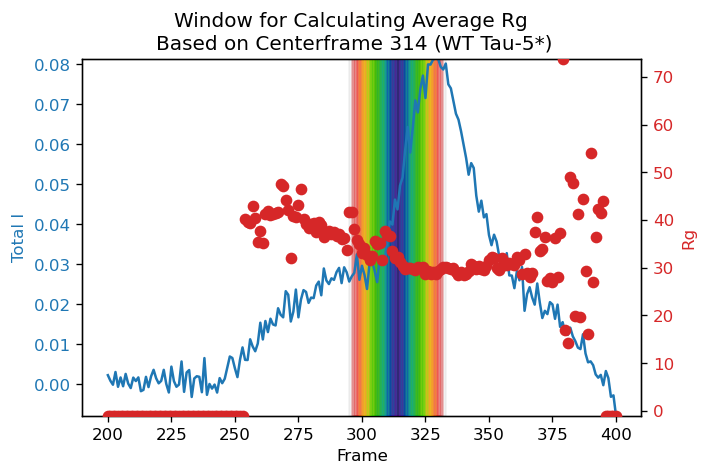

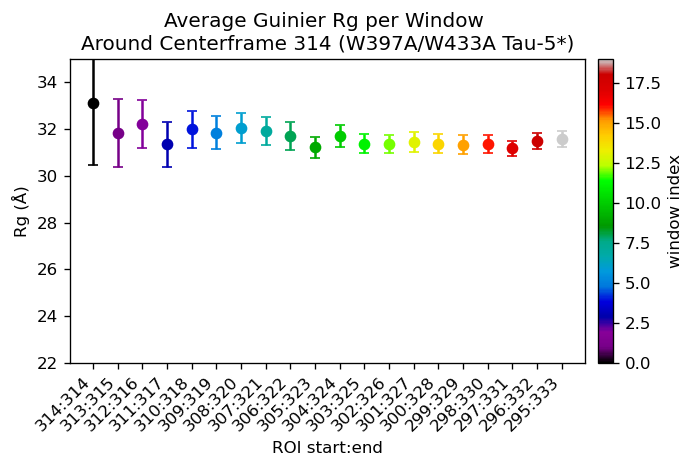

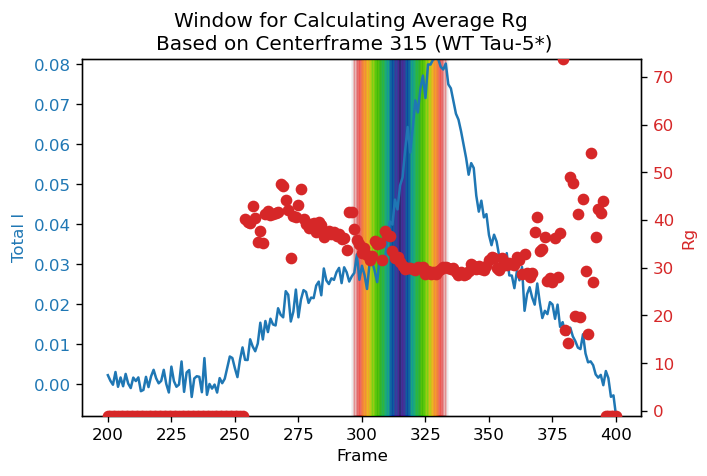

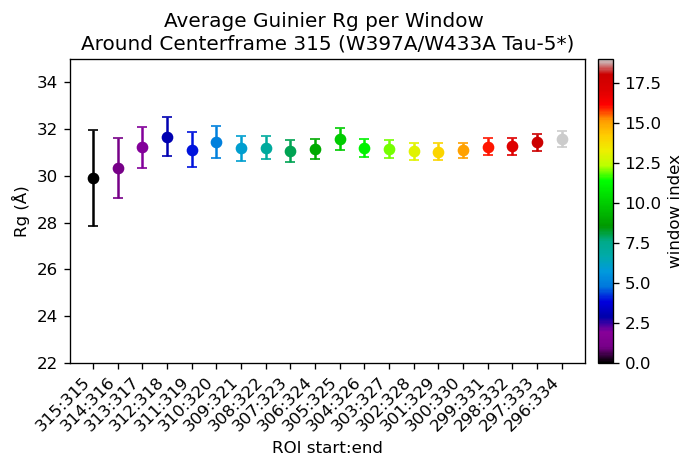

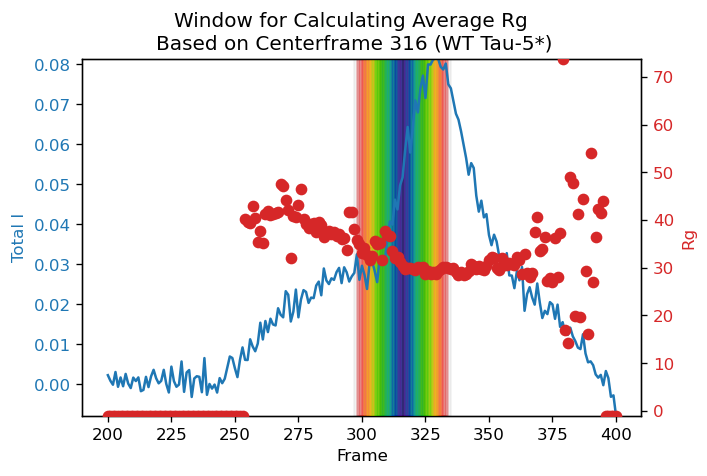

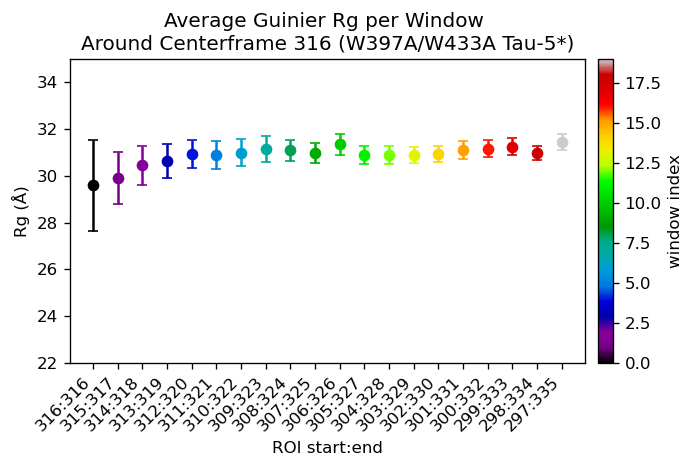

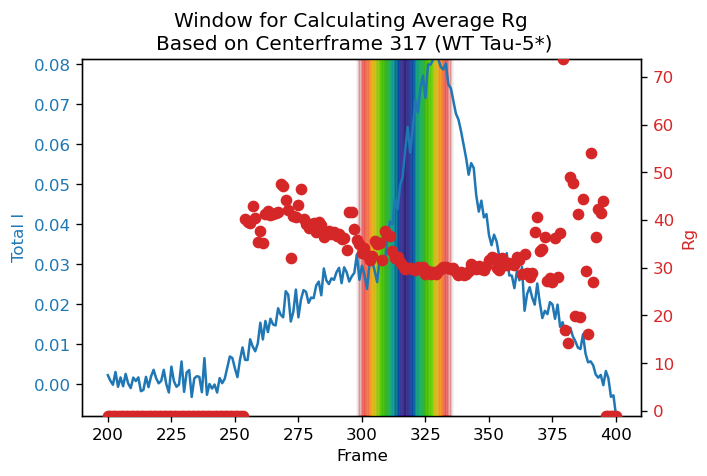

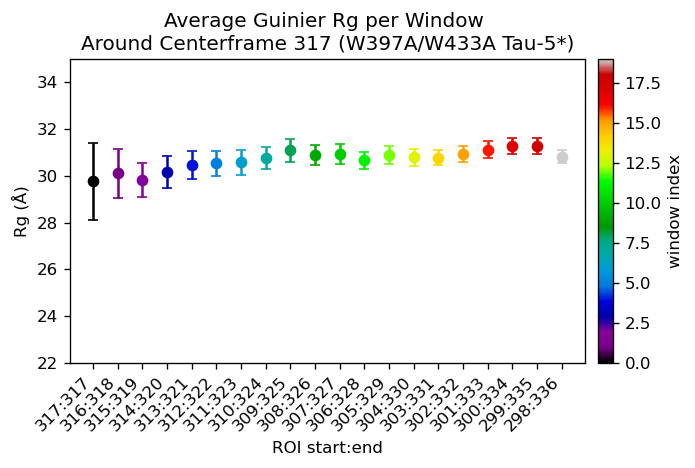

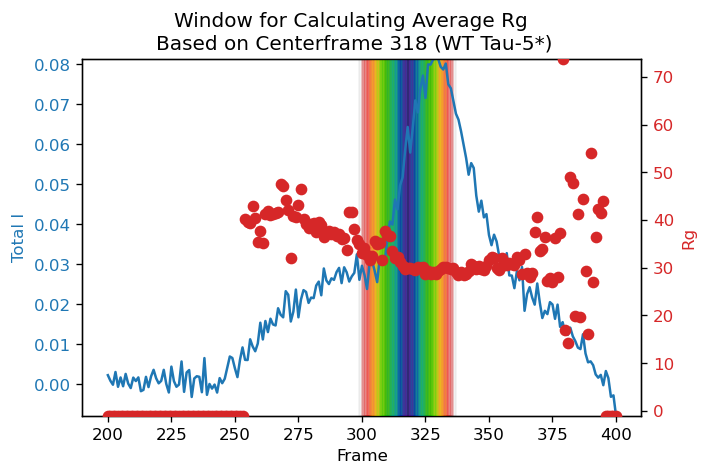

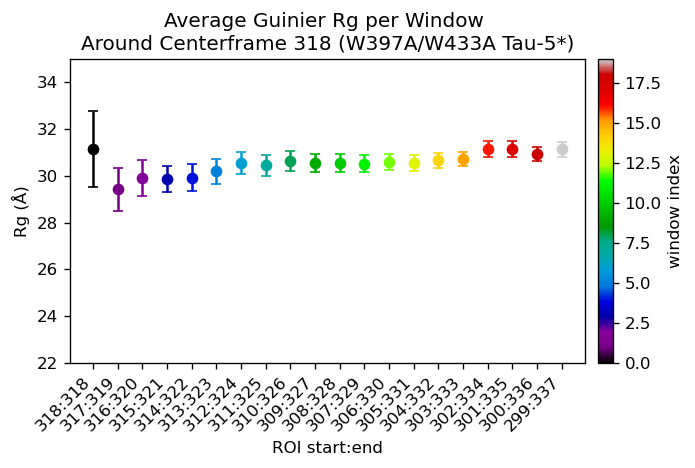

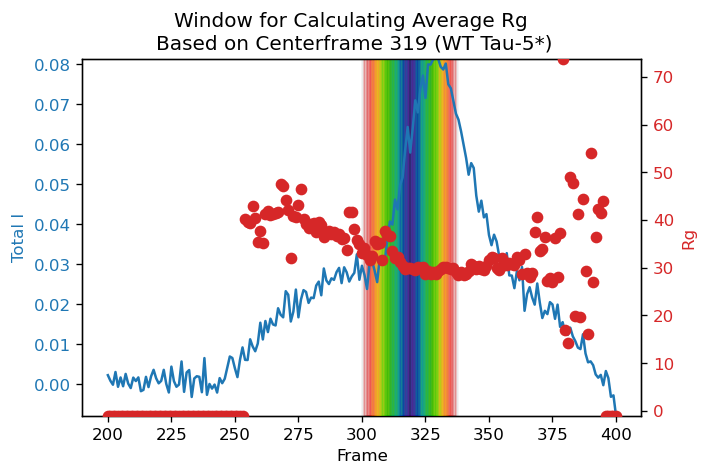

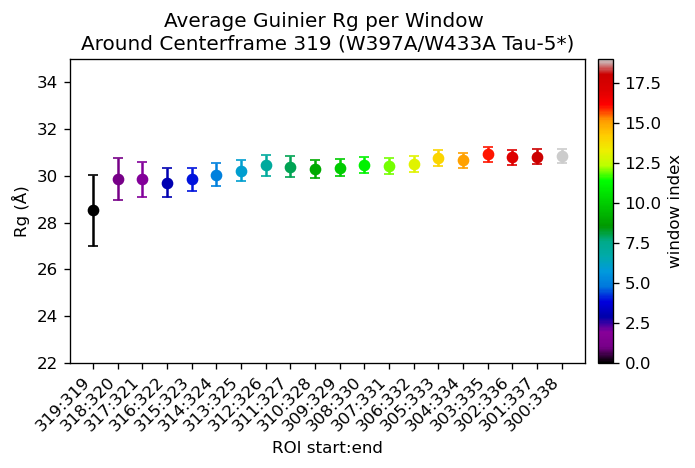

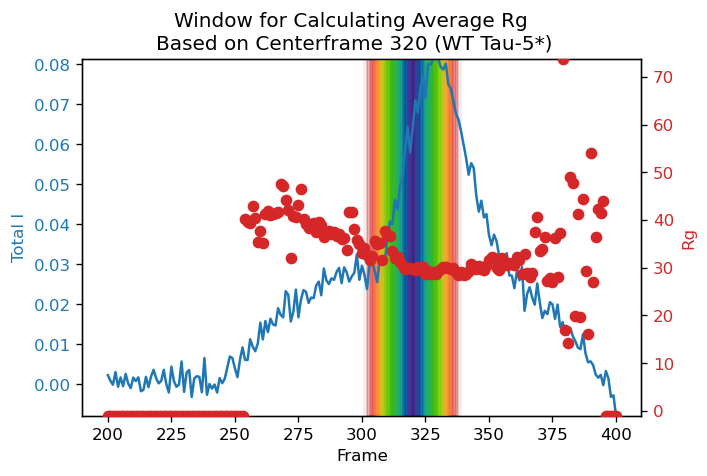

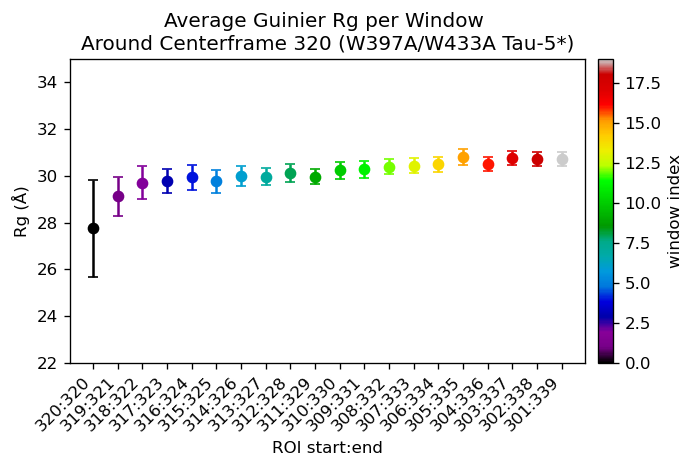

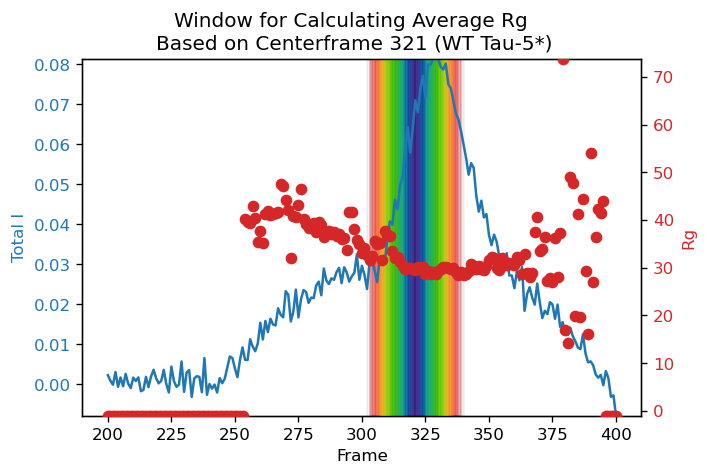

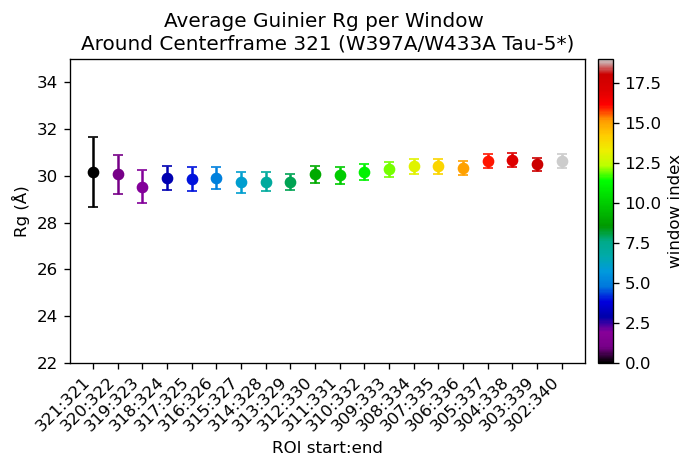

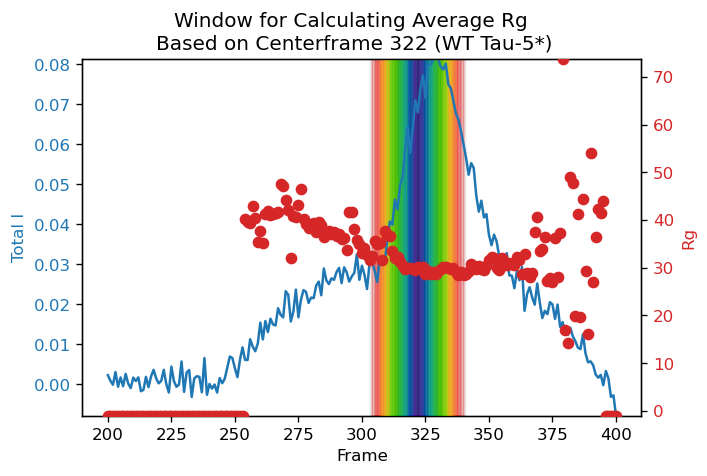

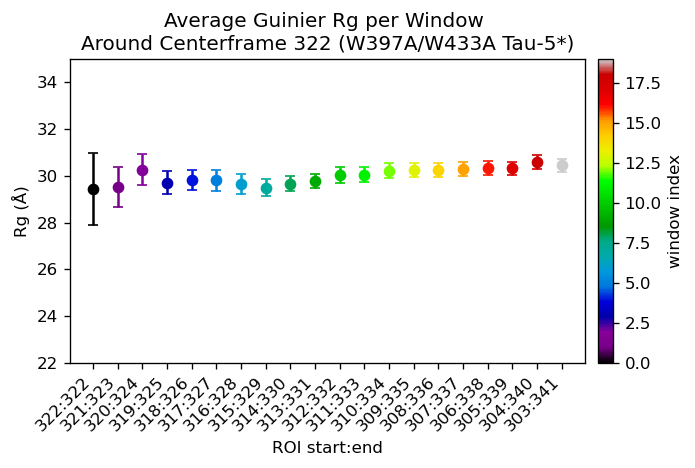

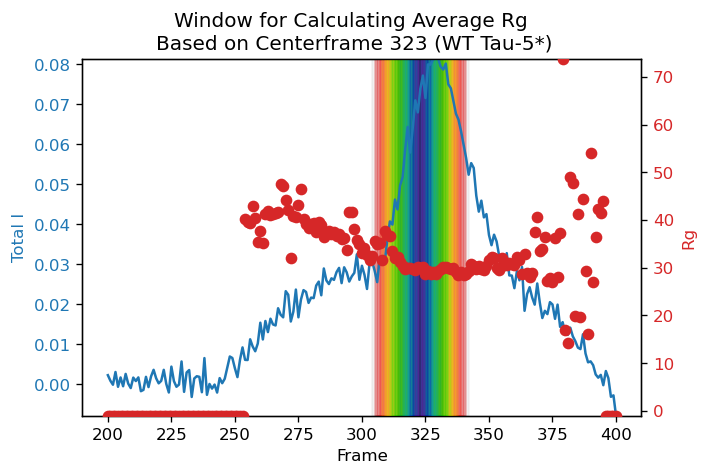

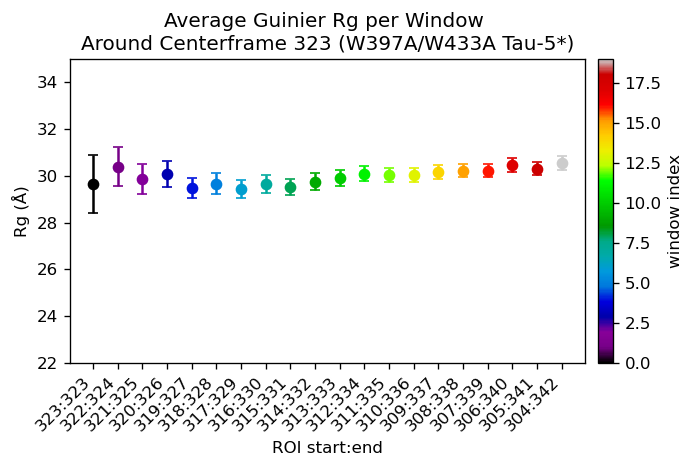

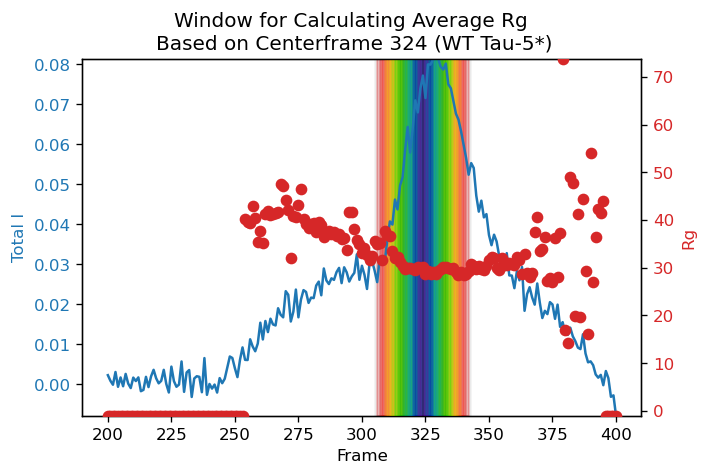

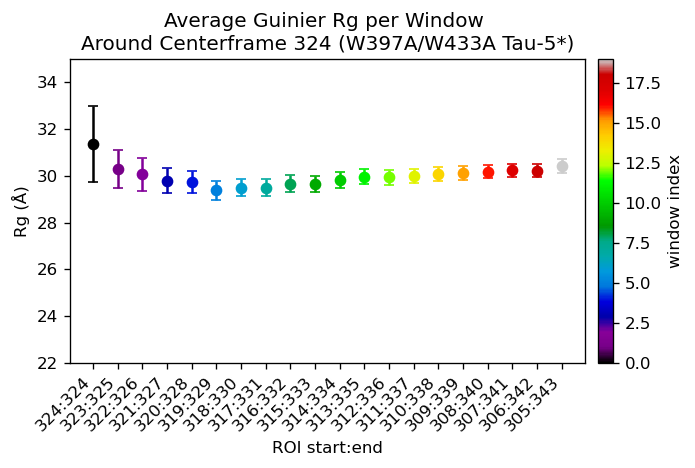

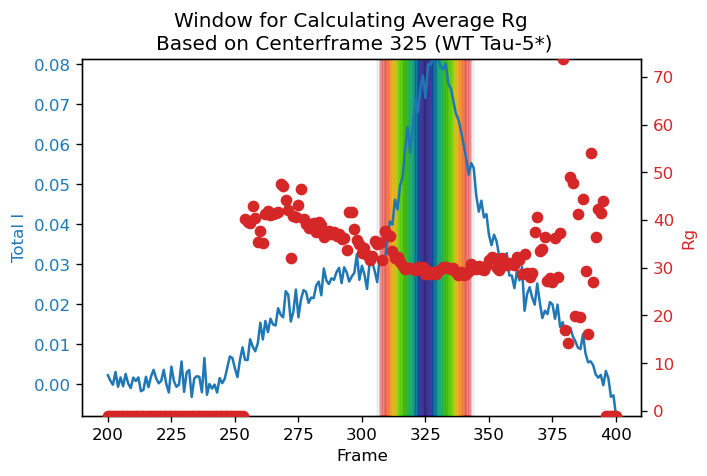

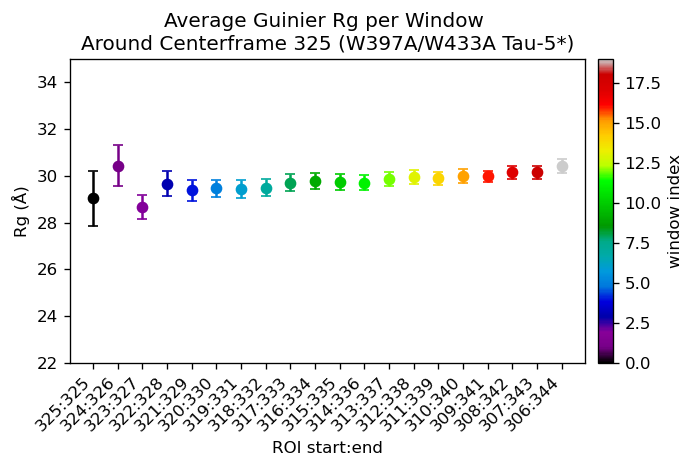

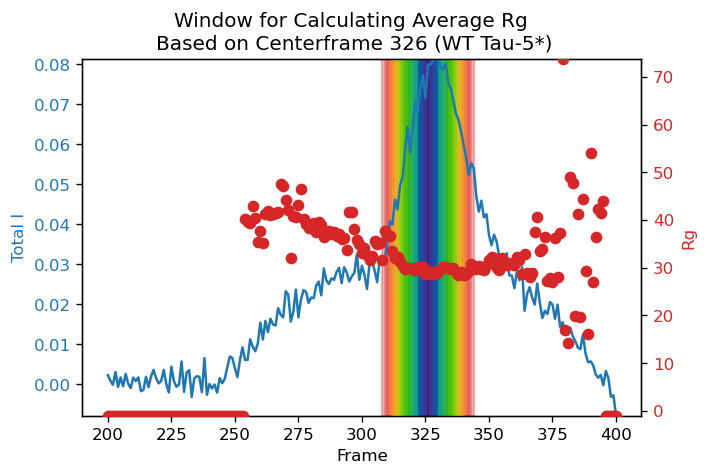

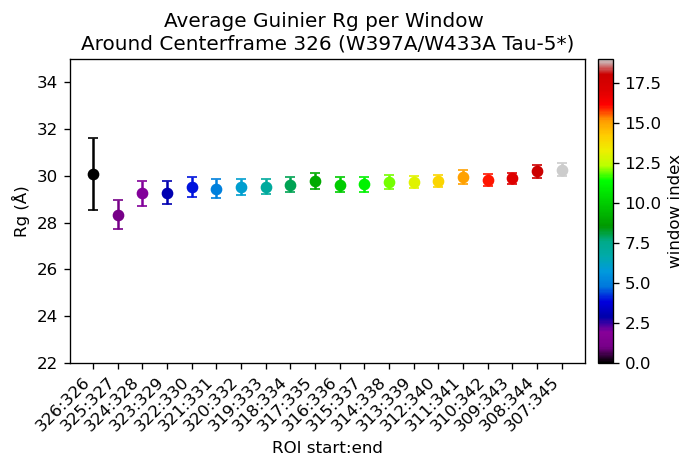

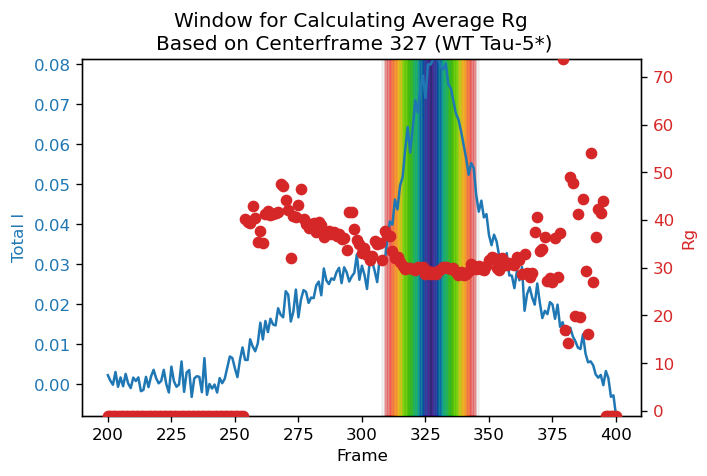

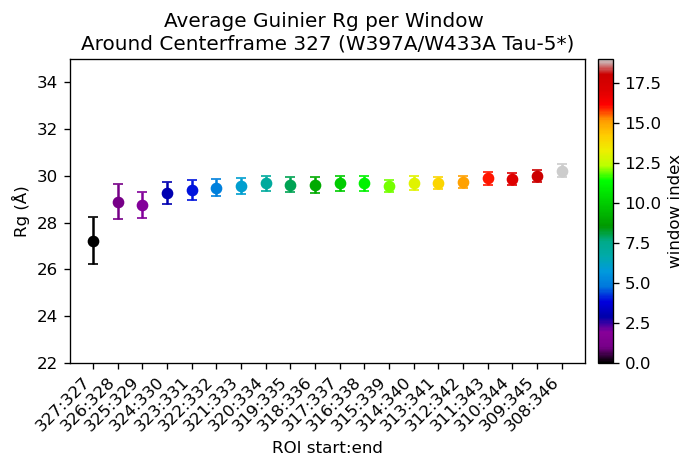

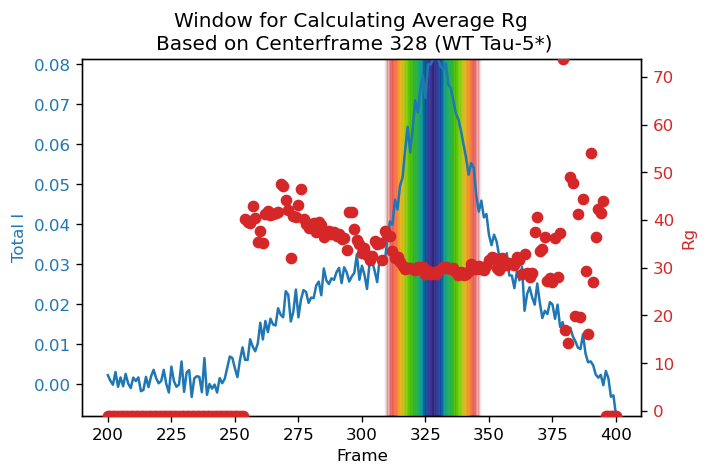

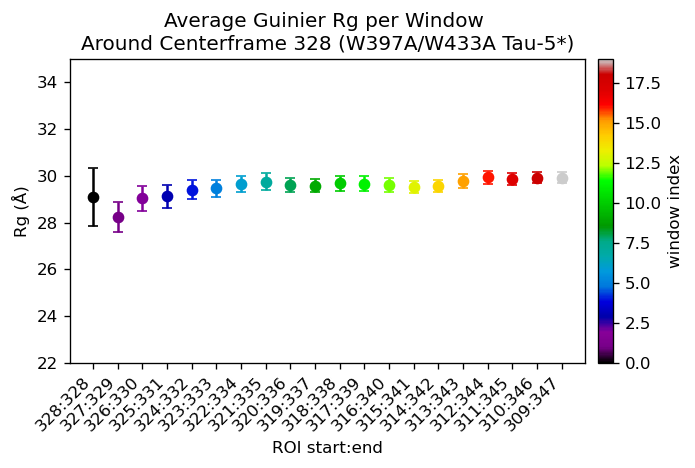

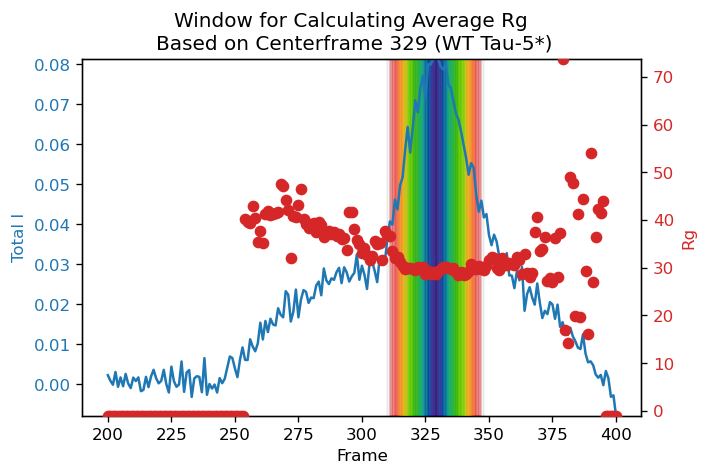

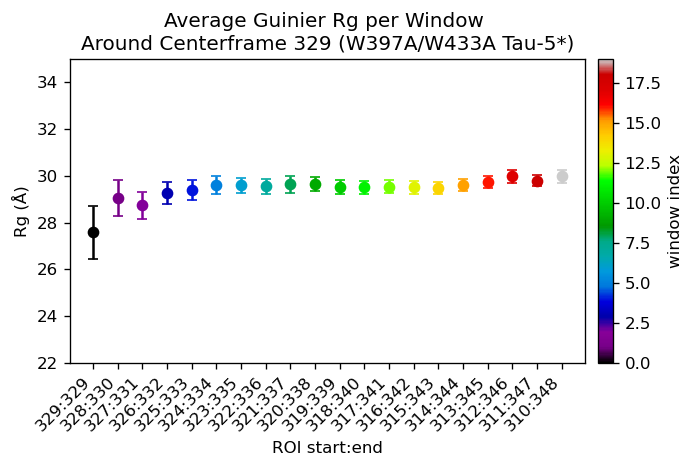

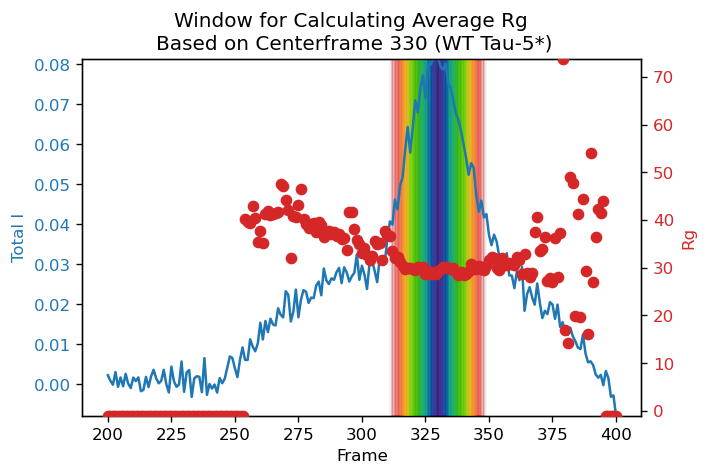

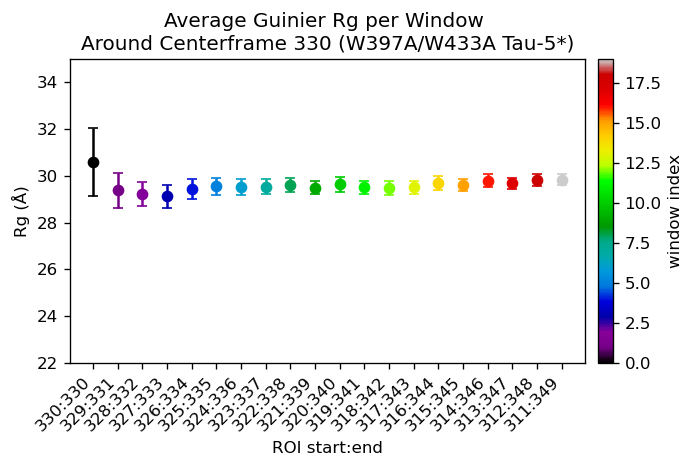

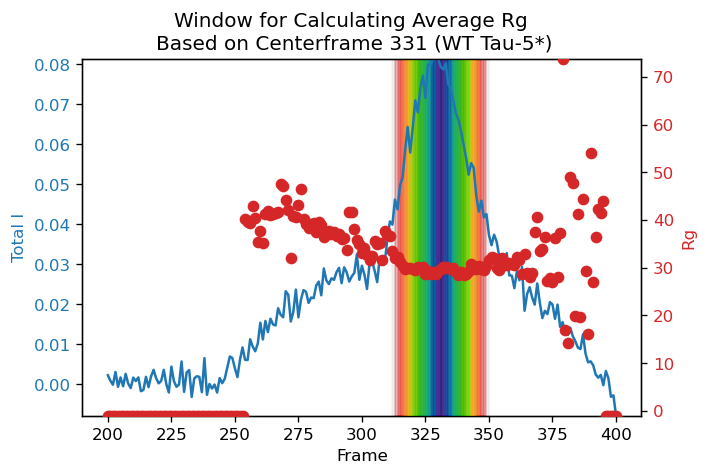

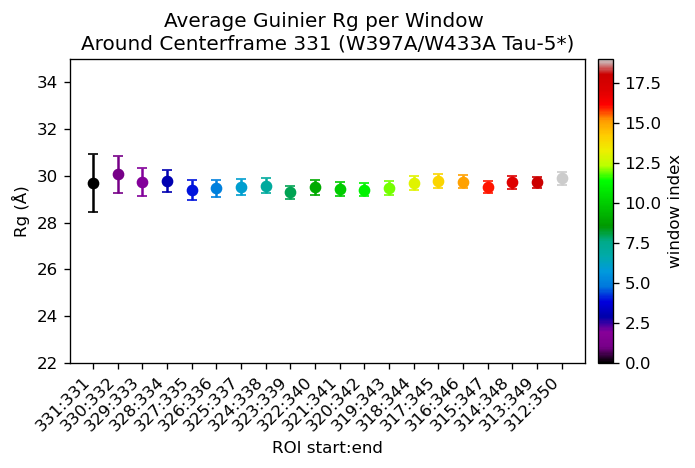

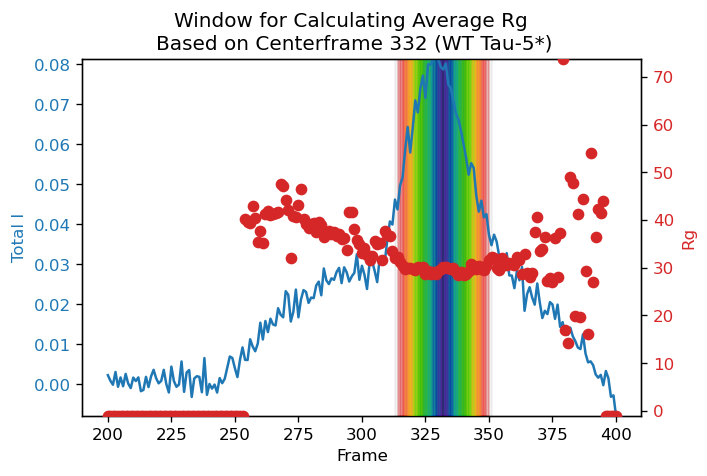

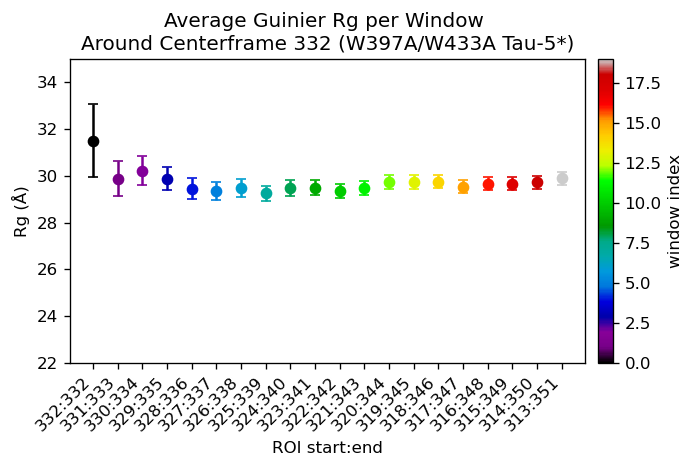

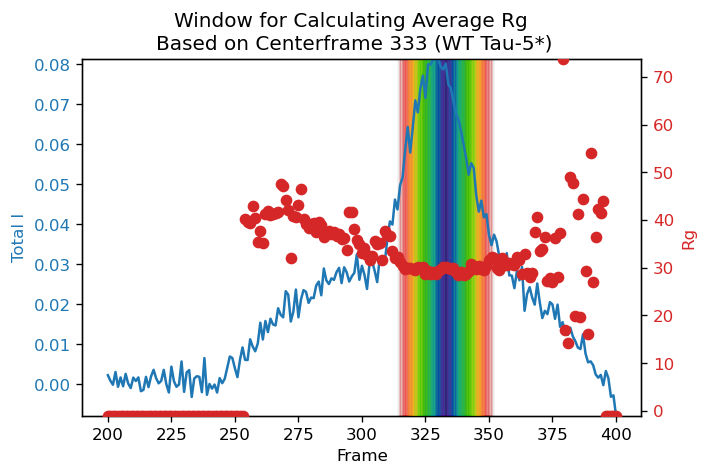

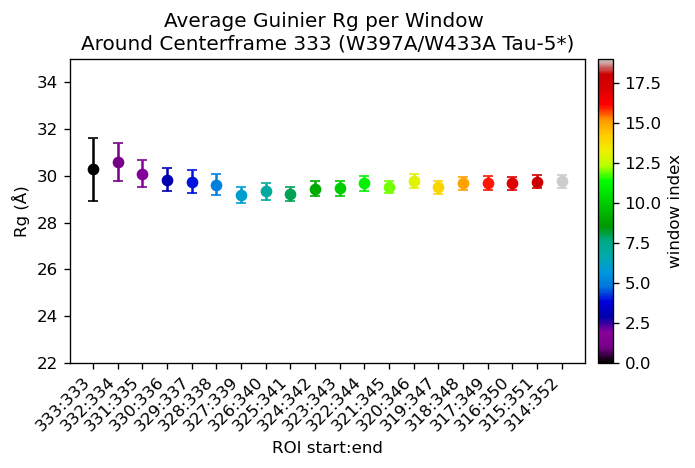

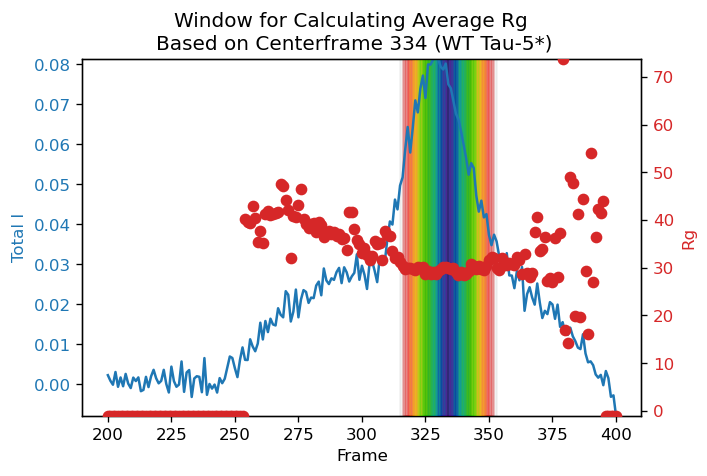

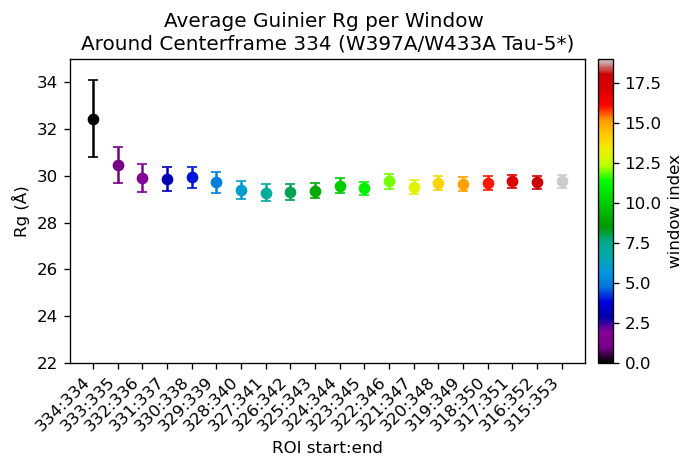

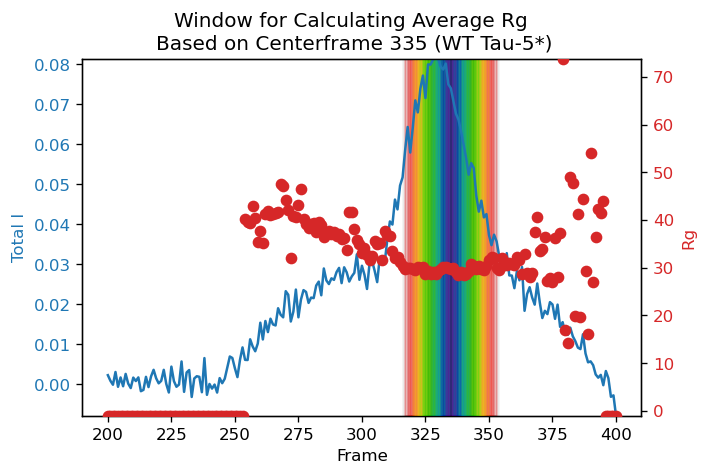

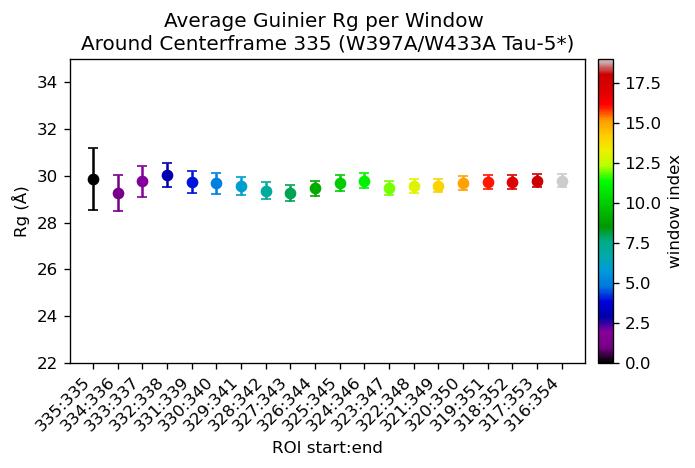

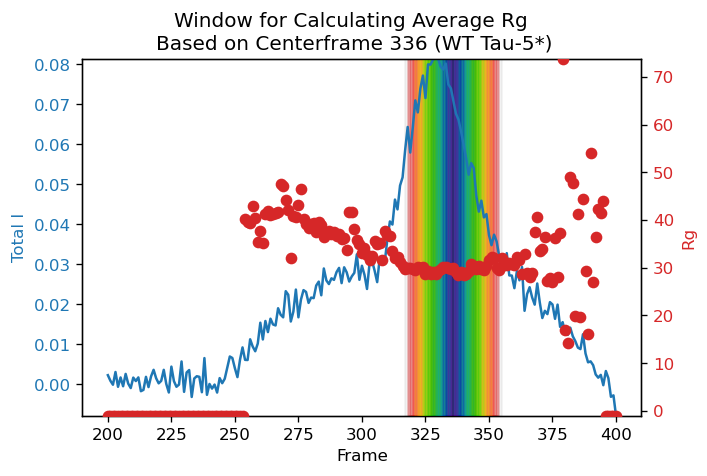

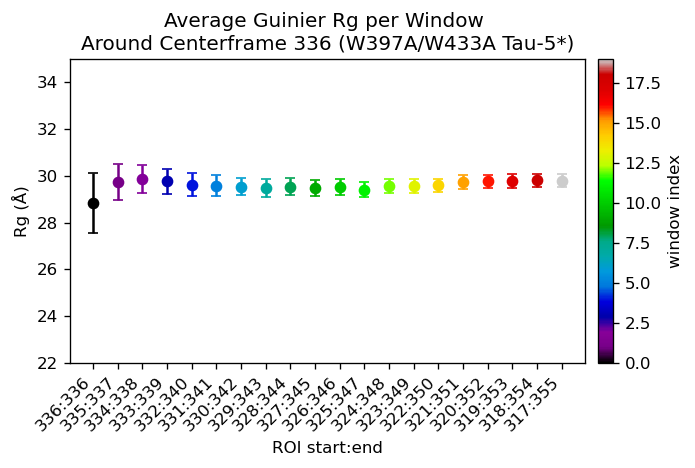

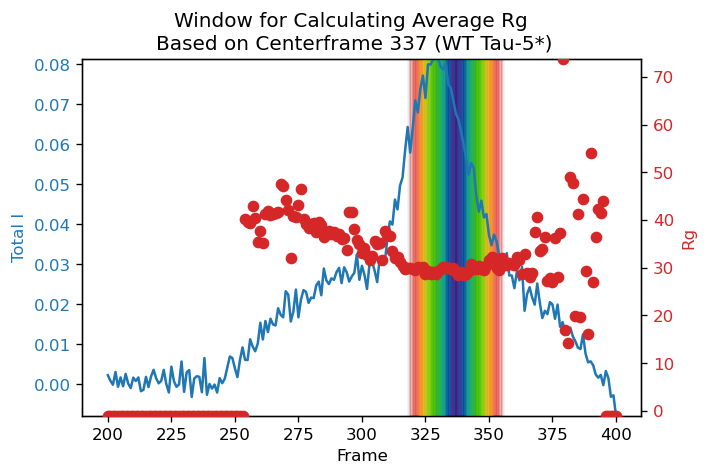

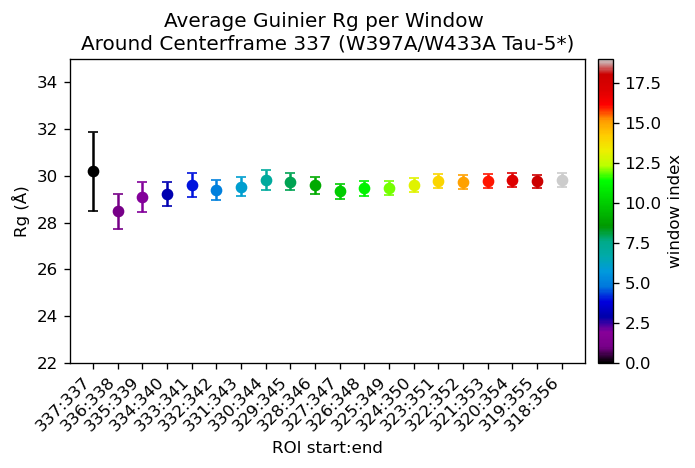

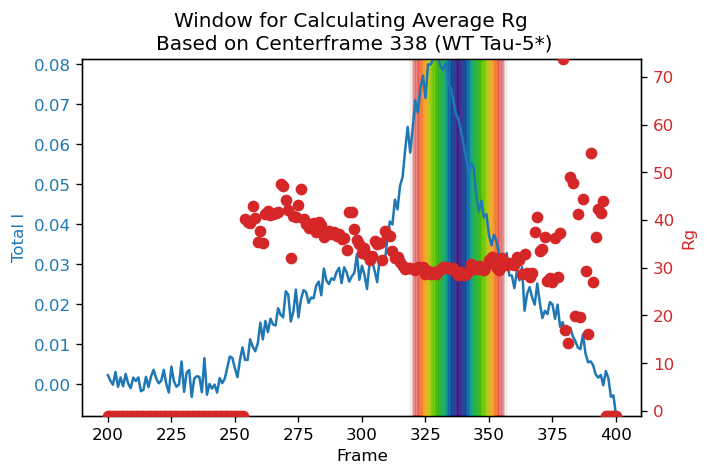

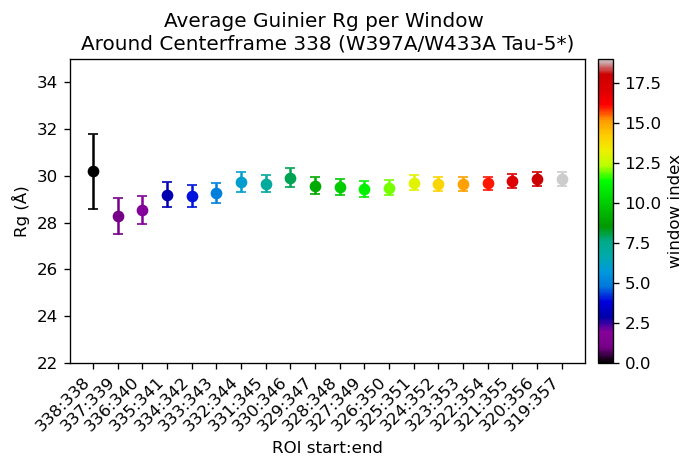

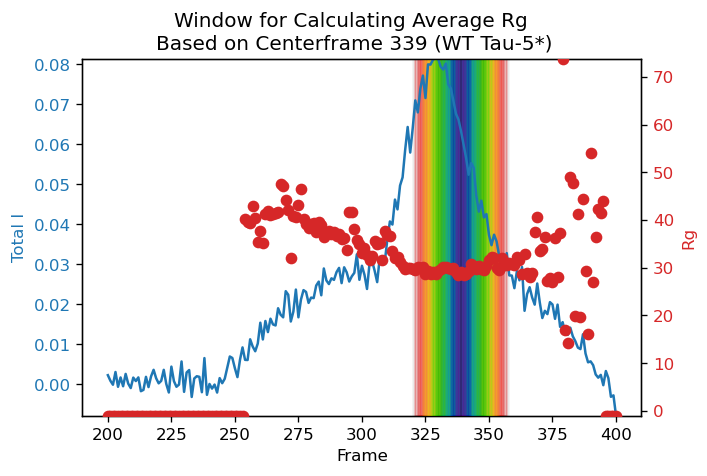

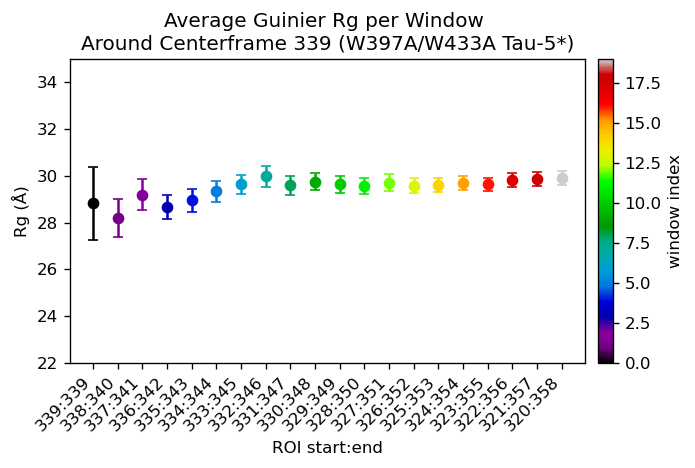

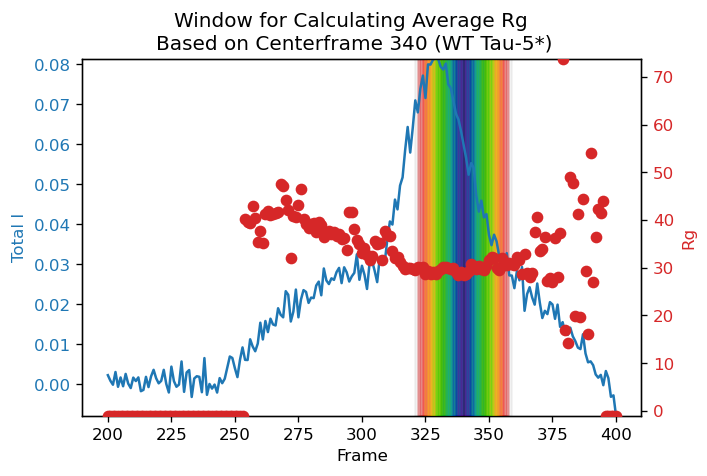

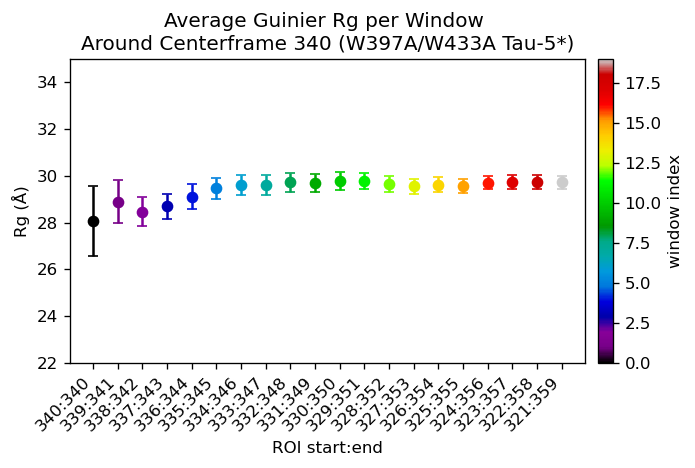

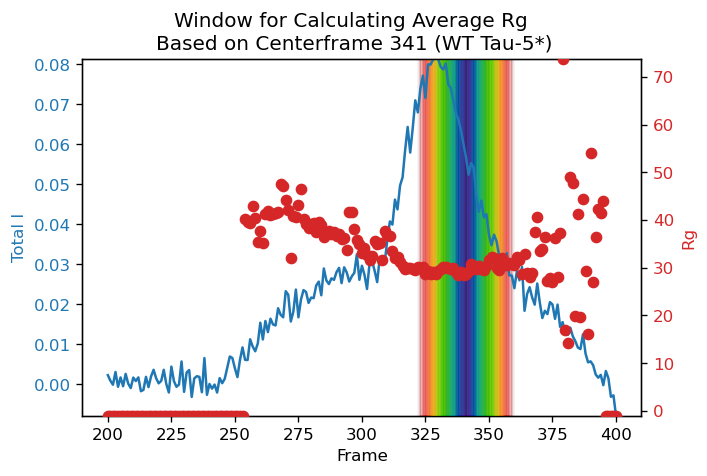

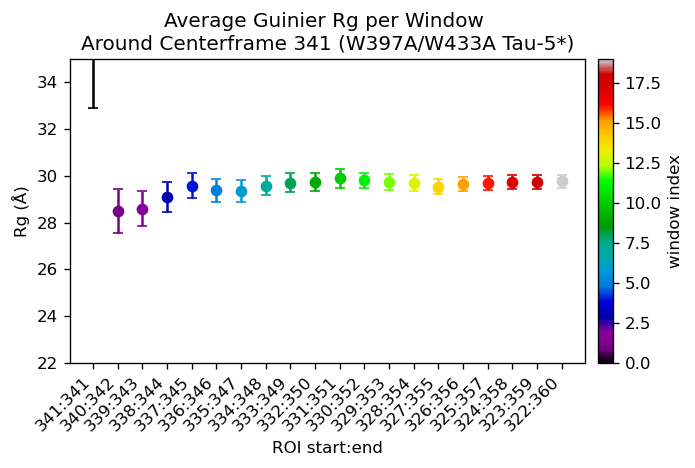

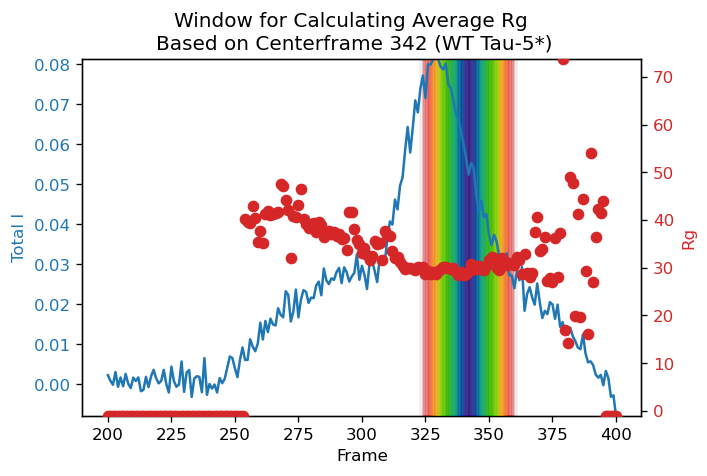

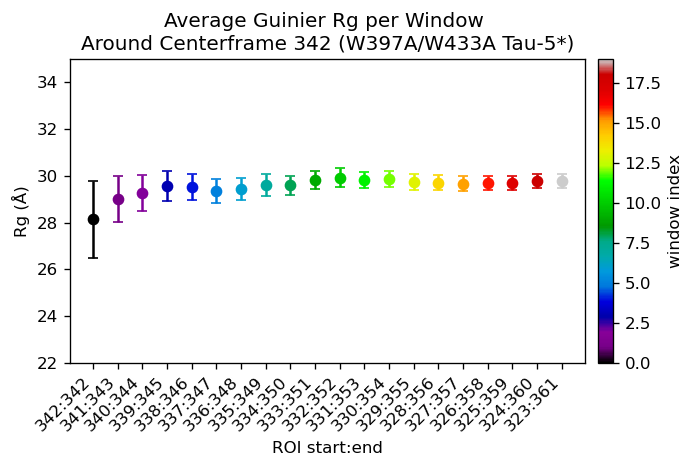

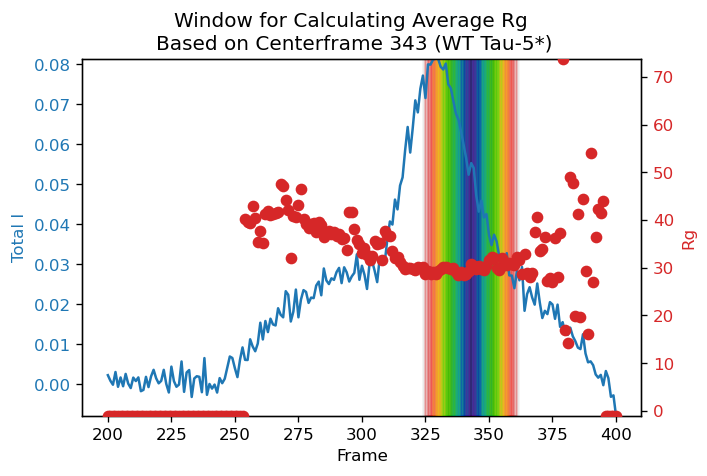

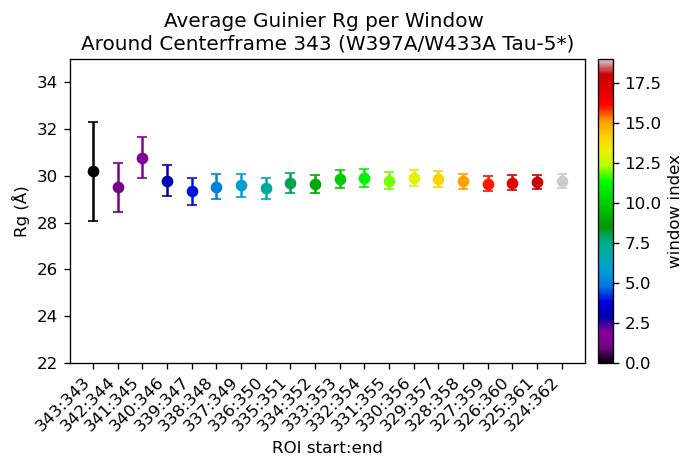

In [45]:
for i in range(range_int):
    centerframe=centerframe_int+i

    # step-wise j values
    steps = list(range(0, step_range_int, 1))
    m = len(steps)

    rg_values = np.full(m, np.nan, dtype=float)
    rg_errors = np.full(m, np.nan, dtype=float)
    x_labels = []

    # prepare colormap and normalizer across indices 0..m-1
    cmap = plt.cm.nipy_spectral
    norm = plt.Normalize(vmin=0, vmax=max(1, m-1))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # for colorbar

    # Plot background once
    fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)
    mask = (frames >= start_frame) & (frames <= end_frame)

    ax1.plot(frames[mask], subtracted_total_i[mask], color='tab:blue', label='Total I', zorder=m+3)
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Total I', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    try:
        ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
        if ymin == ymax:
            ymin -= 0.5; ymax += 0.5
        ax1.set_ylim(ymin, ymax)
    except ValueError:
        pass

    ax2 = ax1.twinx()
    ax2.plot(frames[mask], rg[mask], color='tab:red', marker='o', linestyle='None', label='Rg', zorder=m+4)
    ax2.set_ylabel('Rg', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    try:
        ymin2, ymax2 = np.nanmin(rg[mask]), np.nanmax(rg[mask])
        if ymin2 == ymax2:
            ymin2 -= 0.5; ymax2 += 0.5
        ax2.set_ylim(ymin2, ymax2)
    except ValueError:
        pass

    # draw windows using evenly spaced cmap samples; later windows get lower zorder so last window is behind
    for k, j in enumerate(steps):
        roi_start = int(centerframe - j)
        roi_end = int(centerframe + j)
        x_labels.append(f"{roi_start}:{roi_end}")

        sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')

        color = cmap(norm(k))          # uses full cmap range
        span_z = m - k                 # decreasing z-order for later (higher k) windows
        ax1.axvspan(roi_start, roi_end, color=color, alpha=0.25, zorder=span_z)

        average_profile = raw.average(sub_profiles_roi)
        try:
            (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
            idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
            rg_values[k] = rg_j
            rg_errors[k] = rg_err_j
        except Exception as e:
            print(f"Error processing window j={j} (slice {roi_start}:{roi_end}): {e}")

    # add a colorbar legend for the windows (index)
    # cbar = fig.colorbar(sm, ax=ax1, pad=0.02, orientation='vertical')
    # cbar.set_label('window index (0 → first, higher → wider windows)')

    # reserve space for a larger suptitle and set its font size
    fig.tight_layout(rect=[0, 0, 1, 0.92])            # leave top 8% for title
    fig.suptitle(f'Window for Calculating Average Rg \nBased on Centerframe {centerframe} (WT Tau-5*)', y=0.98)                 # adjust fontsize and vertical position
    plt.show()

    # print("steps:", steps)
    # print("rg_values:", rg_values)
    # print("rg_errors:", rg_errors)

    # Plot rg values with per-point colors matching the cmap
    x = np.arange(len(x_labels))
    fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
    for ii in range(len(x)):
        col = cmap(norm(ii))
        ax.errorbar(x[ii], rg_values[ii], yerr=rg_errors[ii], fmt='o', color=col, capsize=3)

    ax.set_xlabel('ROI start:end')
    ax.set_ylabel('Rg (Å)')
    ax.set_title('Average Guinier Rg per Window \nAround Centerframe ' + str(centerframe)+' (W397A/W433A Tau-5*)')

    if m <= 20:
        ticks = x
    else:
        step = max(1, m // 10)
        ticks = x[::step]

    ax.set_xticks(ticks)
    ax.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')
    ax.set_ylim(bottom=22,top=35)  # Rg cannot be negative, so start y-axis at 0
    # reuse scalar mappable for colorbar on this plot too
    fig.colorbar(sm, ax=ax, pad=0.02).set_label('window index')

    fig.tight_layout()
    plt.show()
#

In [196]:
# Set up output directory and PowerPoint file path
out_dir = 'ppt_results'
os.makedirs(out_dir, exist_ok=True)

prs = Presentation()
# make slide bigger (e.g. 16" x 9")
prs.slide_width = Inches(16)
prs.slide_height = Inches(9)

# margins and gap (adjust to taste)
left_margin = Inches(0.4)
right_margin = Inches(0.4)
gap = Inches(0.2)

# compute available width and split between left/right panels
available = prs.slide_width - left_margin - right_margin - gap
width_left = available * 0.65   # 65% for left panel
width_right = available - width_left

In [ ]:
# Make a slide layout
# Make GIF of background frames and rg frames (if needed)

ppt_path = os.path.join(out_dir, 'rg_windows_slides_comp_WT.pptx')

with tempfile.TemporaryDirectory() as tmpdir:
    bg_files = []   # <-- collect bg frames for GIF
    rg_files = []   # <-- collect rg frames for GIF (if needed)

    for i in range(range_int):
        centerframe=centerframe_int+i

        # step-wise j values
        steps = list(range(0, step_range_int, 1))
        m = len(steps)

        rg_values = np.full(m, np.nan, dtype=float)
        rg_errors = np.full(m, np.nan, dtype=float)
        x_labels = []

        # prepare colormap and normalizer across indices 0..m-1
        cmap = plt.cm.nipy_spectral
        norm = plt.Normalize(vmin=0, vmax=max(1, m-1))
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # for colorbar
        
        # --- create left panel figure (background + windows) ---
        fig_bg = plt.figure(figsize=(10, 6), dpi=150)
        fig_bg.tight_layout(rect=[0, 0, 1, 0.92])            # leave top 8% for title
        fig_bg.suptitle(f'Window for Calculating Average Rg \nBased on Centerframe {centerframe} (WT Tau-5*)',
                         fontsize=18, y=0.98)      
        gs = fig_bg.add_gridspec(1, 1)
        ax_bg = fig_bg.add_subplot(gs[0, 0])

        mask = (frames >= start_frame) & (frames <= end_frame)
        ax_bg.plot(frames[mask], subtracted_total_i[mask], color='tab:blue', label='Total I', zorder=m + 3)
        ax_bg.set_xlabel('Frame')
        ax_bg.set_ylabel('Total I', color='tab:blue')
        ax_bg.tick_params(axis='y', labelcolor='tab:blue')
        try:
            ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
            if ymin == ymax:
                ymin -= 0.5; ymax += 0.5
            ax_bg.set_ylim(ymin, ymax)
        except ValueError:
            pass

        ax2 = ax_bg.twinx()
        ax2.plot(frames[mask], rg[mask], color='tab:red', marker='o', linestyle='None', label='Rg', zorder=m + 4)
        ax2.set_ylabel('Rg', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        for k, j in enumerate(steps):
            roi_start = int(centerframe - j)
            roi_end = int(centerframe + j)
            x_labels.append(f"{roi_start}:{roi_end}")

            sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')

            color = cmap(norm(k))
            span_z = m - k
            ax_bg.axvspan(roi_start, roi_end, color=color, alpha=0.25, zorder=span_z)

            average_profile = raw.average(sub_profiles_roi)
            try:
                (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
                 idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
                rg_values[k] = rg_j
                rg_errors[k] = rg_err_j
            except Exception as e:
                print(f"Error processing window j={j} (slice {roi_start}:{roi_end}): {e}")

        fname_bg = os.path.join(tmpdir, f'bg_{i:03d}.png')
        fig_bg.tight_layout()
        fig_bg.savefig(fname_bg, bbox_inches='tight', dpi=150)
        plt.close(fig_bg)
        bg_files.append(fname_bg)   # <-- add saved bg image to list


        # --- create right panel figure (rg vs window index) ---
        fig_rg = plt.figure(figsize=(6, 4), dpi=150)
        ax_rg = fig_rg.add_subplot(111)
        x = np.arange(len(x_labels))
        for ii in range(len(x)):
            col = cmap(norm(ii))
            ax_rg.errorbar(x[ii], rg_values[ii], yerr=np.abs(rg_errors[ii]), fmt='o', color=col, capsize=3)

        ax_rg.set_xlabel('ROI start:end')
        ax_rg.set_ylabel('Rg (Å)')
        ax_rg.set_title(f'Average Guinier Rg per Window\nAround Centerframe {centerframe}'+ ' (WT Tau-5*)')
        if len(x_labels) <= 20:
            ticks = x
        else:
            step = max(1, len(x_labels) // 10)
            ticks = x[::step]
        
        ax_rg.set_xticks(ticks)
        ax_rg.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')
        ax_rg.set_ylim(bottom=rg_lower_limit, top=rg_upper_limit)
        fig_rg.tight_layout()
        fname_rg = os.path.join(tmpdir, f'rg_{i:03d}.png')
        fig_rg.savefig(fname_rg, bbox_inches='tight', dpi=150)
        plt.close(fig_rg)
        rg_files.append(fname_rg)   # <-- add saved rg image to list

        # Histogram figure for Rg values
        fig_hist = plt.figure(figsize=(4, 3), dpi=150)
        valid = ~np.isnan(rg_values)
        if np.count_nonzero(valid) == 0:
            plt.text(0.5, 0.5, "no valid Rg values", ha='center', va='center')
            plt.axis('off')
        else:
            vals = rg_values[valid]
            # choose bins (you can adjust)
            bins = min(12, max(6, len(vals)))
            plt.hist(vals, bins=bins, color=color, alpha=0.8, edgecolor='k')
            mean_rg = np.mean(vals)
            med_rg = np.median(vals)
            plt.axvline(mean_rg, color='k', linestyle='--', label=f'mean={mean_rg:.2f}')
            plt.axvline(med_rg, color='gray', linestyle=':', label=f'median={med_rg:.2f}')
            plt.xlabel('Rg (Å)')
            plt.ylabel('Count')
            plt.legend()
            plt.title(f'Rg Distribution for Centerframe {centerframe}\n(WT Tau-5*)')
            plt.xlim(left=rg_lower_limit, right=rg_upper_limit)  # Rg cannot be negative, so start x-axis at 0
            plt.tight_layout()
        
        fname_hist = os.path.join(tmpdir, f'hist_{i:03d}.png')
        fig_hist.savefig(fname_hist, bbox_inches='tight', dpi=150)
        plt.close(fig_hist)

        #-----------------------------------------#

        # Create slides of saved images (if needed)
        # --- add a slide and place both images at fixed positions ---
        slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank layout
        # left image position and size
        left = Inches(0.4)
        top = Inches(0.7)
        width_left = Inches(8.5)   # adjust to taste
        slide.shapes.add_picture(fname_bg, left, top, width=width_left)

        # right image position and size
        left_r = left + width_left + Inches(0.2)
        top_r = top
        width_right = Inches(6.0)
        # add right picture and place histogram above bottom by using picture height
        pic_rg = slide.shapes.add_picture(fname_rg, left_r, top_r, width=width_right)
        
        # place histogram higher: use a fraction of the right picture height plus a small padding
        hist_top = top_r + pic_rg.height * 0.5 + Inches(2)   # adjust 0.5 and 0.05 as needed
        slide.shapes.add_picture(fname_hist, left_r, hist_top, width=width_right)

        # print(f"Added slide for centerframe {centerframe}")

        #-------------------------#

    # Create GIFs from saved images
    gif_path = os.path.join(out_dir, 'fig_bg_animation_WT.gif')
    try:
        images = [imageio.imread(f) for f in sorted(bg_files)]
        imageio.mimsave(gif_path, images, duration=2)   # adjust duration (seconds/frame)
        print("Saved GIF:", gif_path)
    except Exception as e:
        print("Failed to create GIF:", e)

    gif_path = os.path.join(out_dir, 'fig_rg_animation_WT.gif')
    try:
        images = [imageio.imread(f) for f in sorted(rg_files)]
        imageio.mimsave(gif_path, images, duration=2)   # adjust duration (seconds/frame)
        print("Saved GIF:", gif_path)
    except Exception as e:
        print("Failed to create GIF:", e)

prs.save(ppt_path)
print("Saved PowerPoint:", ppt_path)

Saved GIF: ppt_results/fig_bg_animation_WT.gif
Saved GIF: ppt_results/fig_rg_animation_WT.gif
Saved PowerPoint: ppt_results/rg_windows_slides_comp_WT.pptx


In [ ]:
# Make power point slides for each centerframe and window range, save bg and rg plots as images, then add to slides
ppt_path = os.path.join(out_dir, 'rg_windows_slides_comp_WT_5.pptx')


with tempfile.TemporaryDirectory() as tmpdir:

    for i in range(range_int):
        centerframe=centerframe_int+i

        # step-wise j values
        steps = list(range(0, 5, 1))
        m = len(steps)

        rg_values = np.full(m, np.nan, dtype=float)
        rg_errors = np.full(m, np.nan, dtype=float)
        x_labels = []

        # prepare colormap and normalizer across indices 0..m-1
        cmap = plt.cm.nipy_spectral
        norm = plt.Normalize(vmin=0, vmax=max(1, m-1))
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # for colorbar
        
        # --- create left panel figure (background + windows) ---
        fig_bg = plt.figure(figsize=(10, 6), dpi=150)
        fig_bg.tight_layout(rect=[0, 0, 1, 0.92])            # leave top 8% for title
        fig_bg.suptitle(f'Window for Calculating Average Rg \nBased on Centerframe {centerframe} (WT Tau-5*)',
                         fontsize=18, y=0.98)      
        gs = fig_bg.add_gridspec(1, 1)
        ax_bg = fig_bg.add_subplot(gs[0, 0])

        mask = (frames >= start_frame) & (frames <= end_frame)
        ax_bg.plot(frames[mask], subtracted_total_i[mask], color='tab:blue', label='Total I', zorder=m + 3)
        ax_bg.set_xlabel('Frame')
        ax_bg.set_ylabel('Total I', color='tab:blue')
        ax_bg.tick_params(axis='y', labelcolor='tab:blue')
        try:
            ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
            if ymin == ymax:
                ymin -= 0.5; ymax += 0.5
            ax_bg.set_ylim(ymin, ymax)
        except ValueError:
            pass

        ax2 = ax_bg.twinx()
        ax2.plot(frames[mask], rg[mask], color='tab:red', marker='o', linestyle='None', label='Rg', zorder=m + 4)
        ax2.set_ylabel('Rg', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        for k, j in enumerate(steps):
            roi_start = int(centerframe - j)
            roi_end = int(centerframe + j)
            x_labels.append(f"{roi_start}:{roi_end}")

            sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')

            color = cmap(norm(k))
            span_z = m - k
            ax_bg.axvspan(roi_start, roi_end, color=color, alpha=0.25, zorder=span_z)

            average_profile = raw.average(sub_profiles_roi)
            try:
                (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
                 idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
                rg_values[k] = rg_j
                rg_errors[k] = rg_err_j
            except Exception as e:
                print(f"Error processing window j={j} (slice {roi_start}:{roi_end}): {e}")

        fname_bg = os.path.join(tmpdir, f'bg_{i:03d}.png')
        fig_bg.tight_layout()
        fig_bg.savefig(fname_bg, bbox_inches='tight', dpi=150)
        plt.close(fig_bg)
        bg_files.append(fname_bg)   # <-- add saved bg image to list


        # --- create right panel figure (rg vs window index) ---
        fig_rg = plt.figure(figsize=(6, 4), dpi=150)
        ax_rg = fig_rg.add_subplot(111)
        x = np.arange(len(x_labels))
        for ii in range(len(x)):
            col = cmap(norm(ii))
            ax_rg.errorbar(x[ii], rg_values[ii], yerr=np.abs(rg_errors[ii]), fmt='o', color=col, capsize=3)

        ax_rg.set_xlabel('ROI start:end')
        ax_rg.set_ylabel('Rg (Å)')
        ax_rg.set_title(f'Average Guinier Rg per Window\nAround Centerframe {centerframe}'+ ' (WT Tau-5*)')
        if len(x_labels) <= 20:
            ticks = x
        else:
            step = max(1, len(x_labels) // 10)
            ticks = x[::step]
        
        ax_rg.set_xticks(ticks)
        ax_rg.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')
        ax_rg.set_ylim(bottom=rg_lower_limit, top=rg_upper_limit)
        fig_rg.tight_layout()
        fname_rg = os.path.join(tmpdir, f'rg_{i:03d}.png')
        fig_rg.savefig(fname_rg, bbox_inches='tight', dpi=150)
        plt.close(fig_rg)

        # Histogram figure for Rg values
        fig_hist = plt.figure(figsize=(4, 3), dpi=150)
        valid = ~np.isnan(rg_values)
        if np.count_nonzero(valid) == 0:
            plt.text(0.5, 0.5, "no valid Rg values", ha='center', va='center')
            plt.axis('off')
        else:
            vals = rg_values[valid]
            # choose bins (you can adjust)
            bins = min(12, max(6, len(vals)))
            plt.hist(vals, bins=bins, color=color, alpha=0.8, edgecolor='k')
            mean_rg = np.mean(vals)
            med_rg = np.median(vals)
            plt.axvline(mean_rg, color='k', linestyle='--', label=f'mean={mean_rg:.2f}')
            plt.axvline(med_rg, color='gray', linestyle=':', label=f'median={med_rg:.2f}')
            plt.xlabel('Rg (Å)')
            plt.ylabel('Count')
            plt.legend()
            plt.title(f'Rg Distribution for Centerframe {centerframe}\n(WT Tau-5*)')
            plt.xlim(left=rg_lower_limit, right=rg_upper_limit)  # Rg cannot be negative, so start x-axis at 0
            plt.tight_layout()
        fname_hist = os.path.join(tmpdir, f'hist_{i:03d}.png')
        fig_hist.savefig(fname_hist, bbox_inches='tight', dpi=150)
        plt.close(fig_hist)

        # --- add a slide and place both images at fixed positions ---
        slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank layout
        # left image position and size
        left = Inches(0.4)
        top = Inches(0.7)
        width_left = Inches(8.5)   # adjust to taste
        slide.shapes.add_picture(fname_bg, left, top, width=width_left)

        # right image position and size
        left_r = left + width_left + Inches(0.2)
        top_r = top
        width_right = Inches(6.0)
        # add right picture and place histogram above bottom by using picture height
        pic_rg = slide.shapes.add_picture(fname_rg, left_r, top_r, width=width_right)
        
        # place histogram higher: use a fraction of the right picture height plus a small padding
        hist_top = top_r + pic_rg.height * 0.5 + Inches(2)   # adjust 0.5 and 0.05 as needed
        slide.shapes.add_picture(fname_hist, left_r, hist_top, width=width_right)

        print(f"Added slide for centerframe {centerframe}")

    prs.save(ppt_path)
    print("Saved PowerPoint:", ppt_path)

Added slide for centerframe 315
Added slide for centerframe 316
Added slide for centerframe 317
Added slide for centerframe 318
Added slide for centerframe 319
Added slide for centerframe 320
Added slide for centerframe 321
Added slide for centerframe 322
Added slide for centerframe 323
Added slide for centerframe 324
Added slide for centerframe 325
Added slide for centerframe 326
Added slide for centerframe 327
Added slide for centerframe 328
Added slide for centerframe 329
Added slide for centerframe 330
Added slide for centerframe 331
Added slide for centerframe 332
Added slide for centerframe 333
Added slide for centerframe 334
Added slide for centerframe 335
Added slide for centerframe 336
Added slide for centerframe 337
Added slide for centerframe 338
Added slide for centerframe 339
Added slide for centerframe 340
Added slide for centerframe 341
Added slide for centerframe 342
Added slide for centerframe 343
Added slide for centerframe 344
Added slide for centerframe 345
Added sl

### Average Profiles 

In [46]:
# Define a region of interest (ROI) for analysis, zero indexed
roi_start = int(330)
roi_end = int(340)

#Get profiles from the series in a given range, zero indexed
profiles_roi = my_series.getSASMList(roi_start, roi_end)
sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'baseline')


In [47]:
average_profile = raw.average(sub_profiles_roi[:])
average_profile

In [48]:
# AverageProfile 
q_avg=average_profile.getQ()
intensity_avg=average_profile.getI()
error_avg=average_profile.getErr()

Text(0, 0.5, 'Intensity (I)')

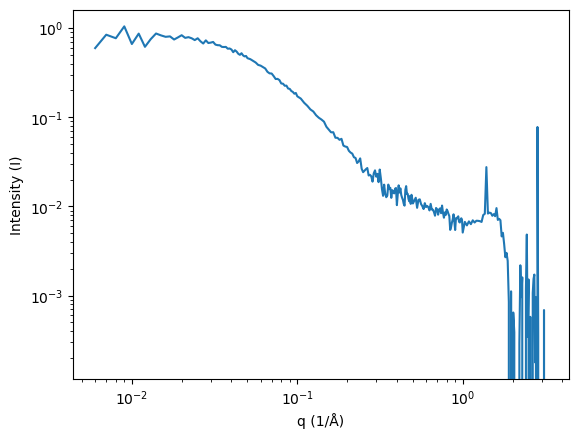

In [49]:
# Average curve
plt.Figure(figsize=(8,6), dpi=120)
plt.plot(q_avg, intensity_avg, linestyle='-', marker=None)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


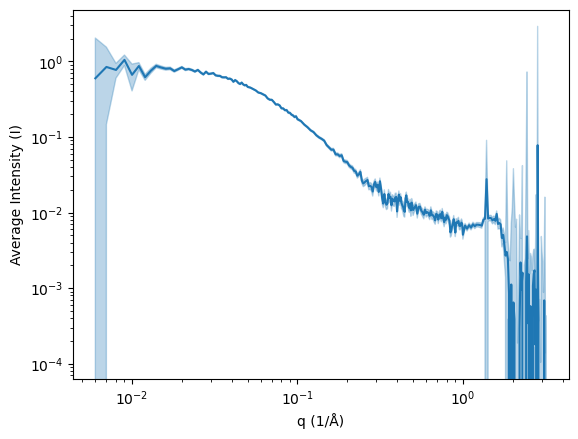

In [50]:
# Plot the average q and intensity data as Log-Log
line, = plt.plot(q_avg, intensity_avg, label='Intensity (normalized)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Average Intensity (I)')
plt.fill_between(
    q_avg,
    intensity_avg - error_avg,
    intensity_avg + error_avg,
    alpha=0.3,
    color=line.get_color()
)
# plt.xlim(0.005, 0.6)
plt.show()
 

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_23458/16234987.py:15: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0.00, 0.6)


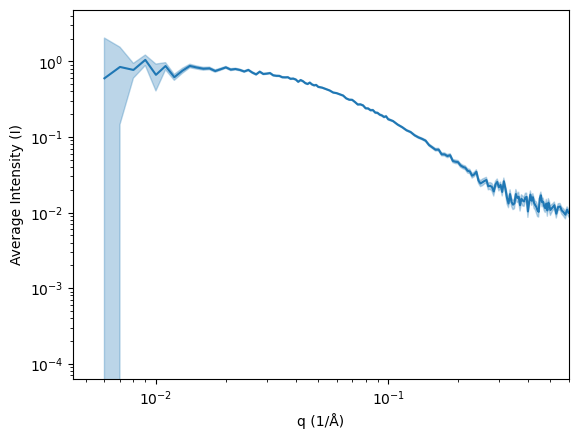

In [51]:
# Plot the average q and intensity data as Log-Log
line, = plt.plot(q_avg, intensity_avg, label='Intensity (normalized)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Average Intensity (I)')
plt.fill_between(
    q_avg,
    intensity_avg - error_avg,
    intensity_avg + error_avg,
    alpha=0.3,
    color=line.get_color()
)
plt.xlim(0.00, 0.6)
plt.show()
 

#### Analyze Average of ROI

In [52]:
#Automatically calculate the Guinier range and fit
(rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
    r_sq) = raw.auto_guinier(average_profile, settings=my_settings)

print(f"Guinier fit results for {average_profile}")
print(f"i0: {i0:.3e} ± {i0_err:.3e}")
print(f"Rg: {rg:.3e} ± {rg_err:.3e}")
print(f"Guinier fit R²: {r_sq:.4f}")
print(f"Guinier range: q = {qmin:.3e} to {qmax:.3e}")
print(f"Guinier range used Rg: q = {qrg_min:.3e} to {qrg_max:.3e}")
print(f"idx_min: {idx_min}, idx_max: {idx_max}")

Guinier fit results for <bioxtasraw.SASM.SASM object at 0x327572f50>
i0: 8.670e-01 ± 8.213e-03
Rg: 2.783e+01 ± 3.757e-01
Guinier fit R²: 0.9650
Guinier range: q = 1.400e-02 to 4.700e-02
Guinier range used Rg: q = 3.896e-01 to 1.308e+00
idx_min: 8, idx_max: 41


In [53]:
# AverageProfile 
q=average_profile.getQ()
intensity = average_profile.getI()
error = average_profile.getErr()

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_23458/334467498.py:10: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity)


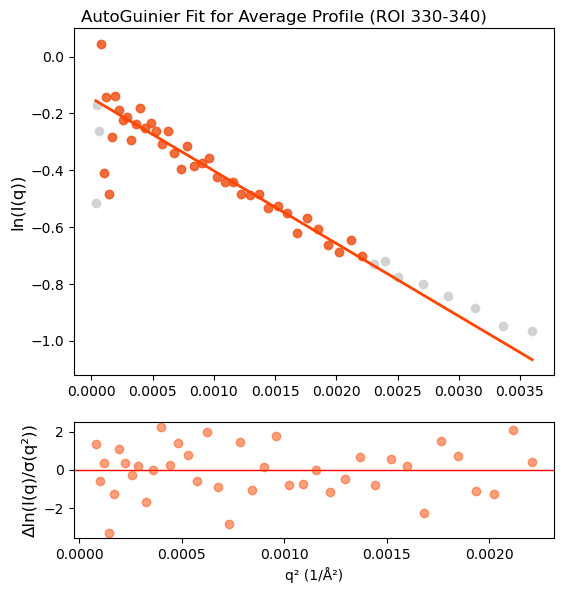

In [64]:
# Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

# Plot Some points of the data for context
q_sq = q**2
i_ln = np.log(intensity)
qmin_sq = qmin**2
qmax_sq = qmax**2
axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o', 
         linestyle='None', color='lightgray', label='Data')
axs[0].set_ylabel('ln(I(q))', fontsize=12)

# Plot the AutoGuinier fit data points
mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
            label='Guinier points', color=colorAA, alpha=0.7)

# Line for the Guinier fit
# optional: fit a straight line to the selected Guinier points
if np.count_nonzero(mask) >= 2:
   #Get fit r squared:
    x = np.square(q[idx_min:idx_max+1])
    y = np.log(intensity[idx_min:idx_max+1])
    sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
    
    a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

    y_fit = SASCalc.linear_func(x, a, b)
    y_line= SASCalc.linear_func(q_sq[0:50], a, b)
    
    gui_err = y - y_fit
    residuals = gui_err / sigma  # weighted residuals
    
    # Plot line of best fit
    axs[0].plot(q_sq[0:50], y_line, '-', label=f'Guinier fit: slope={a:.3e}', 
             color=colorAA, alpha=1, linewidth=2.0, zorder=100)
    
    # Plot residuals in second subplot
    axs[1].plot(x, residuals, marker='o', linestyle='None', color=colorAA, alpha=0.5)
    
    # Set up labels for residuals subplot
    axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
    axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
    axs[1].tick_params(axis='both', labelsize=10)

# Plot Specifications
plt.xlabel('q² (1/Å²)')
plt.suptitle(f'AutoGuinier Fit for Average Profile (ROI {roi_start}-{roi_end})')
plt.show()


Fit with idx_min=0, idx_max=41: Rg=2.770e+01 ± 3.726e-01, R²=0.7004
Fit with idx_min=1, idx_max=41: Rg=2.770e+01 ± 3.726e-01, R²=0.8017
Fit with idx_min=2, idx_max=41: Rg=2.770e+01 ± 3.726e-01, R²=0.7942
Fit with idx_min=3, idx_max=41: Rg=2.770e+01 ± 3.727e-01, R²=0.7996
Fit with idx_min=4, idx_max=41: Rg=2.768e+01 ± 3.735e-01, R²=0.8073
Fit with idx_min=5, idx_max=41: Rg=2.768e+01 ± 3.736e-01, R²=0.8652
Fit with idx_min=6, idx_max=41: Rg=2.768e+01 ± 3.746e-01, R²=0.8567
Fit with idx_min=7, idx_max=41: Rg=2.778e+01 ± 3.745e-01, R²=0.9550
Fit with idx_min=8, idx_max=41: Rg=2.783e+01 ± 3.757e-01, R²=0.9650
Fit with idx_min=9, idx_max=41: Rg=2.777e+01 ± 3.800e-01, R²=0.9656
Fit with idx_min=10, idx_max=41: Rg=2.775e+01 ± 3.848e-01, R²=0.9634
Fit with idx_min=11, idx_max=41: Rg=2.777e+01 ± 3.896e-01, R²=0.9616
Fit with idx_min=12, idx_max=41: Rg=2.776e+01 ± 3.955e-01, R²=0.9589
Fit with idx_min=13, idx_max=41: Rg=2.789e+01 ± 4.006e-01, R²=0.9647
Fit with idx_min=14, idx_max=41: Rg=2.791e+0

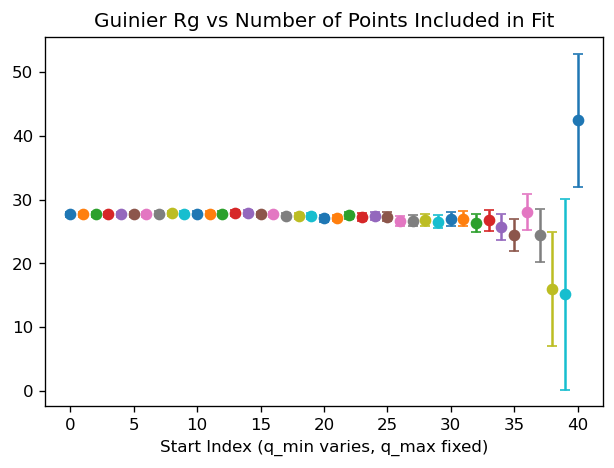

In [55]:
# Iteratively calculate the Guinier range for the average profile, excluding one point at a time from the high-q end, to see how Rg changes

n_points = idx_max # start with a few points beyond the initial idx_max to see the trend
plt.figure(figsize=(6,4), dpi=120)
plt.title('Guinier Rg vs Number of Points Included in Fit')
plt.xlabel('Start Index (q_min varies, q_max fixed)')

for i in range(n_points):
    # Calculate the Guinier range and fit using specified index range

    idx_min = i
    idx_max = n_points
    try:
        (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
            r_sq) = raw.guinier_fit(average_profile, idx_min,idx_max)
        print(f"Fit with idx_min={idx_min}, idx_max={idx_max}: Rg={rg:.3e} ± {rg_err:.3e}, R²={r_sq:.4f}")
    except Exception as e:
        print(f"Error fitting Guinier profile at iteration {i}: {e}")
        continue

    plt.errorbar(idx_min, rg, yerr=rg_err, fmt='o')


Fit with idx_min=0, idx_max=51: Rg=2.587e+01 ± 3.636e-01, R²=0.8944
Fit with idx_min=1, idx_max=51: Rg=2.587e+01 ± 3.634e-01, R²=0.9258
Fit with idx_min=2, idx_max=51: Rg=2.587e+01 ± 3.649e-01, R²=0.9238
Fit with idx_min=3, idx_max=51: Rg=2.587e+01 ± 3.184e-01, R²=0.9238
Fit with idx_min=4, idx_max=51: Rg=2.586e+01 ± 3.206e-01, R²=0.9378
Fit with idx_min=5, idx_max=51: Rg=2.587e+01 ± 3.220e-01, R²=0.9519
Fit with idx_min=6, idx_max=51: Rg=2.586e+01 ± 3.235e-01, R²=0.9515
Fit with idx_min=7, idx_max=51: Rg=2.589e+01 ± 3.256e-01, R²=0.9773
Fit with idx_min=8, idx_max=51: Rg=2.590e+01 ± 3.267e-01, R²=0.9784
Fit with idx_min=9, idx_max=51: Rg=2.587e+01 ± 3.283e-01, R²=0.9802
Fit with idx_min=10, idx_max=51: Rg=2.585e+01 ± 3.315e-01, R²=0.9801
Fit with idx_min=11, idx_max=51: Rg=2.584e+01 ± 3.353e-01, R²=0.9794
Fit with idx_min=12, idx_max=51: Rg=2.583e+01 ± 3.389e-01, R²=0.9789
Fit with idx_min=13, idx_max=51: Rg=2.585e+01 ± 3.076e-01, R²=0.9790
Fit with idx_min=14, idx_max=51: Rg=2.582e+0

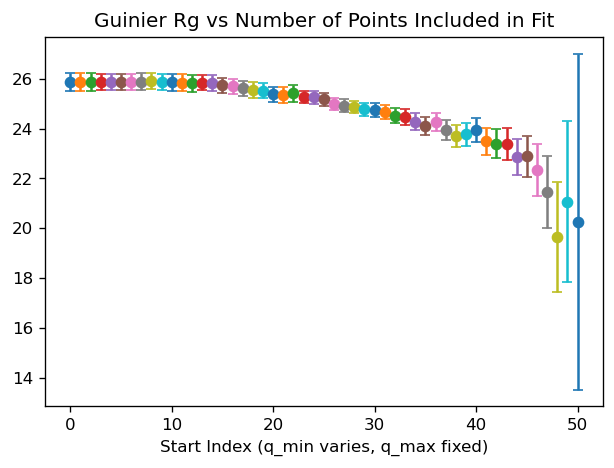

In [56]:
# Iteratively calculate the Guinier range for the average profile, excluding one point at a time from the high-q end, to see how Rg changes

(rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
    r_sq) = raw.auto_guinier(average_profile, settings=my_settings)

n_points = idx_max+10 # start with a few points beyond the initial idx_max to see the trend
plt.figure(figsize=(6,4), dpi=120)
plt.title('Guinier Rg vs Number of Points Included in Fit')
plt.xlabel('Start Index (q_min varies, q_max fixed)')

for i in range(n_points):
    # Calculate the Guinier range and fit using specified index range

    idx_min = i
    idx_max = n_points
    try:
        (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
            r_sq) = raw.guinier_fit(average_profile, idx_min,idx_max)
        print(f"Fit with idx_min={idx_min}, idx_max={idx_max}: Rg={rg:.3e} ± {rg_err:.3e}, R²={r_sq:.4f}")
    except Exception as e:
        print(f"Error fitting Guinier profile at iteration {i}: {e}")
        continue

    plt.errorbar(idx_min, rg, yerr=rg_err, fmt='o')

    



In [72]:
# Manual Guinier fit using a specified index range, for example idx_min=1, idx_max=45
# Calculate the Guinier range and fit using specified index range

idx_min = 1
idx_max = 41

(rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
    r_sq) = raw.guinier_fit(average_profile, idx_min,idx_max)

print(f"i0: {i0:.3e} ± {i0_err:.3e}")
print(f"Rg: {rg:.3e} ± {rg_err:.3e}")
print(f"Guinier fit R²: {r_sq:.4f}")
print(f"Guinier range: q = {qmin:.3e} to {qmax:.3e}")
print(f"Guinier range used Rg: q = {qrg_min:.3e} to {qrg_max:.3e}")
print(f"idx_min: {idx_min}, idx_max: {idx_max}")

i0: 8.639e-01 ± 8.051e-03
Rg: 2.770e+01 ± 3.726e-01
Guinier fit R²: 0.8017
Guinier range: q = 7.000e-03 to 4.700e-02
Guinier range used Rg: q = 1.939e-01 to 1.302e+00
idx_min: 1, idx_max: 41


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_23458/2057622334.py:11: RuntimeWarning: invalid value encountered in log
  I_ln = np.log(intensity)


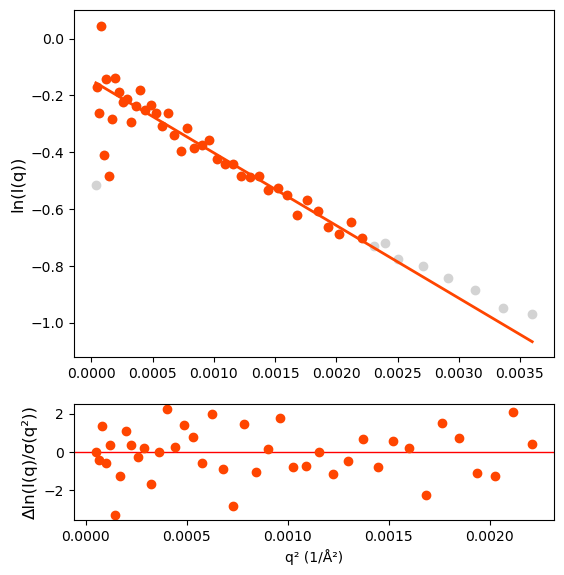

In [73]:
# Plot the q and intensity data from Manual Guinier plot (ln(I) vs q^2)

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)


# Plot points [0:50] of the data for context
q_sq = q ** 2
I_ln = np.log(intensity)

axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o', 
         linestyle='None', color='lightgray', label='Data')
axs[0].set_ylabel('ln(I(q))', fontsize=12)

# Plot the ManualGuinier fit data points
qmin_sq = qmin**2
qmax_sq = qmax**2

mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
            label='Guinier points', color=colorAA)


# Line for the Manual Guinier fit
if np.count_nonzero(mask) >= 2:
   #Get fit r squared:
    x = np.square(q[idx_min:idx_max+1])
    y = np.log(intensity[idx_min:idx_max+1])
    sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
    
    a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

    y_fit = SASCalc.linear_func(x, a, b)
    y_line= SASCalc.linear_func(q_sq[0:50], a, b)

    gui_err = y - y_fit
    residuals = gui_err / sigma  # weighted residuals
    
    # Plot line of best fit
    axs[0].plot(q_sq[0:50], y_line, '-', label=f'Guinier fit: slope={a:.3e}', 
             color=colorAA, alpha=1, linewidth=2.0, zorder=100)
    
    # Plot residuals in second subplot
    axs[1].plot(x, residuals, marker='o', linestyle='None', color=colorAA)
    
    # Set up labels for residuals subplot
    axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
    axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
    axs[1].tick_params(axis='both', labelsize=10)
    
plt.xlabel('q² (1/Å²)')
# plt.ylabel('ln(I)')
plt.show()

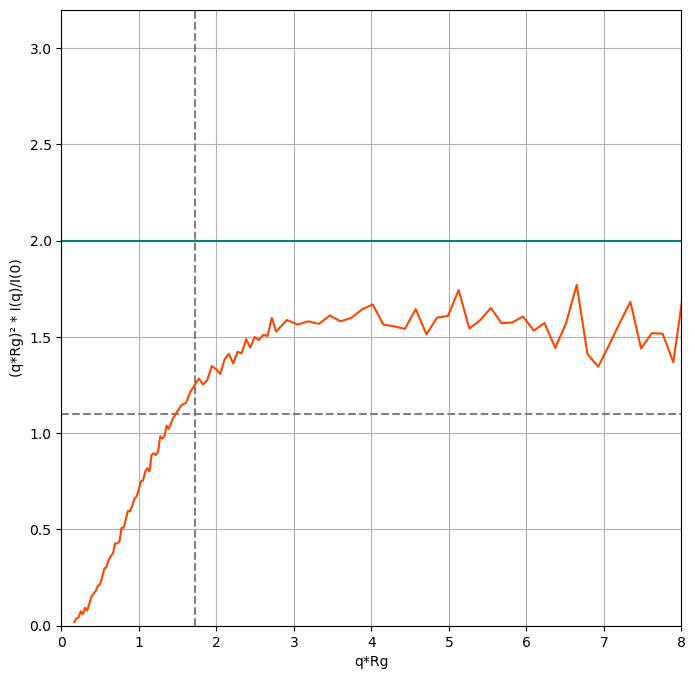

In [66]:
# Kratky Analysis

# Calculate Kratky parameters
xkrat = q * rg 
ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0

# Set up plot
plt.figure(figsize=(8,8))        
plt.xlabel('q*Rg')
plt.ylabel('(q*Rg)² * I(q)/I(0)')

plt.axvline(x=1.73, color='grey', linestyle='--')
plt.axhline(y=1.1, color='grey', linestyle='--', label='1.1')
plt.axhline(y=2, color='teal', linestyle='-') 
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 3.2) 

# Plot Kratky curve
plt.plot(xkrat, ykrat, linestyle='-', color=colorAA, label='Kratky plot')

Auto-determined Dmax: 98.00 Å
GNOM fit results for Dmax=98 Å:
Dmax: 98.00 Å
Rg: 2.898e+01 ± 4.625e-01 Å
i0: 8.701e-01


Text(0, 0.5, 'P(Rg) / I0')

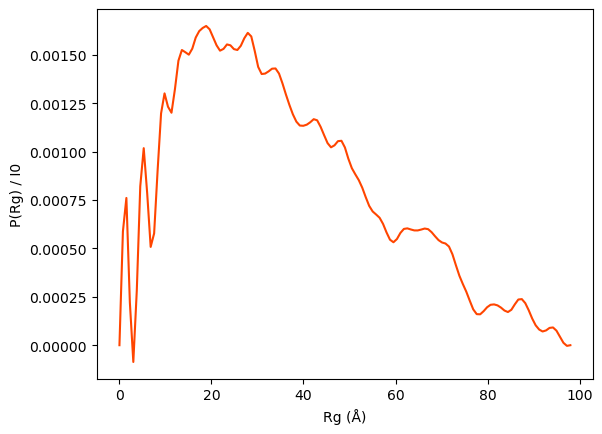

In [67]:
#Use the auto_dmax function to find the best Dmax and then calculate the IFT using GNOM
dmax = raw.auto_dmax(average_profile)
print(f"Auto-determined Dmax: {dmax:.2f} Å")

(gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
    gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
    gi_gnom_quality) = raw.gnom(average_profile, dmax)

print(f"GNOM fit results for Dmax={dmax} Å:")
print(f"Dmax: {gi_gnom_dmax:.2f} Å")
print(f"Rg: {gi_gnom_rg:.3e} ± {gi_gnom_rg_err:.3e} Å")

iftm = gi_gnom_ift

i0 = float(iftm.getParameter('i0'))
print(f"i0: {i0:.3e}")

# Set Plot Specifications
plt.plot(iftm.r, iftm.p/i0, color=colorAA)
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

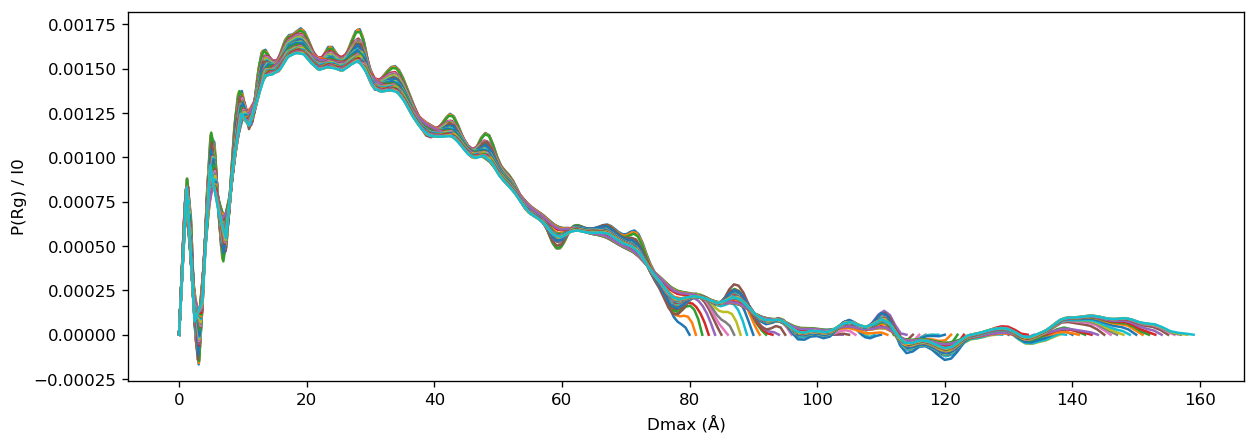

In [61]:
dmax_values = np.arange(80, 160, 1)

plt.figure(figsize=(12,4), dpi=120)
plt.xlabel('Dmax (Å)')
plt.ylabel('P(Rg) / I0')

for dmax in dmax_values:
    try:
        (gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
            gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
            gi_gnom_quality) = raw.gnom(average_profile, dmax)
        # print(f"Dmax: {gi_gnom_dmax:.2f} Å, Rg: {gi_gnom_rg:.2f} Å ± {gi_gnom_rg_err:.2f} Å")
        
        iftm = gi_gnom_ift
        i0 = float(iftm.getParameter('i0'))

        plt.plot(iftm.r, iftm.p/i0, label = f'Dmax={dmax} Å')

    except Exception as e:
        print(f"Error fitting GNOM with Dmax={dmax} Å: {e}")

# plt.legend()

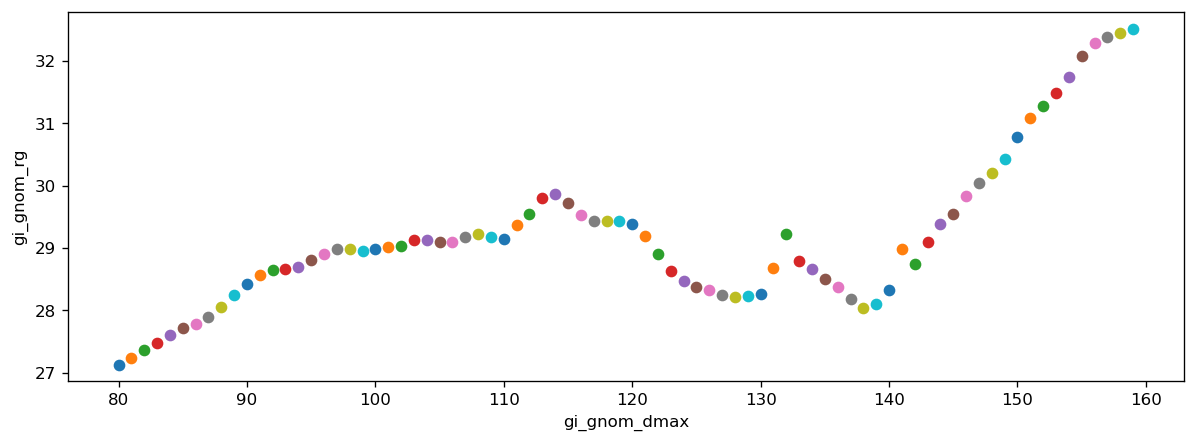

In [62]:
dmax_values = np.arange(80, 160, 1)

plt.figure(figsize=(12,4), dpi=120)
plt.xlabel('gi_gnom_dmax')
plt.ylabel('gi_gnom_rg')

for dmax in dmax_values:
    try:
        (gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
            gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
            gi_gnom_quality) = raw.gnom(average_profile, dmax)
        # print(f"Dmax: {gi_gnom_dmax:.2f} Å, Rg: {gi_gnom_rg:.2f} Å ± {gi_gnom_rg_err:.2f} Å")
        
        plt.plot(gi_gnom_dmax, gi_gnom_rg,'o', label = f'Dmax={dmax} Å')

    except Exception as e:
        print(f"Error fitting GNOM with Dmax={dmax} Å: {e}")

# plt.legend()

GNOM fit results for Dmax=111.0 Å:
Dmax: 111.00 Å
Rg: 2.937e+01 ± 5.939e-01 Å
i0: 8.752e-01


Text(0, 0.5, 'P(Rg) / I0')

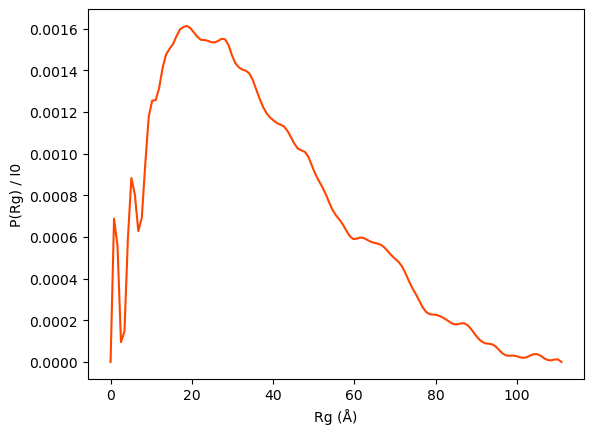

In [70]:
# Use known Dmax to calculate the IFT using GNOM

dmax = 111.0  # example Dmax value in Å

(gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
    gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
    gi_gnom_quality) = raw.gnom(average_profile, dmax)

print(f"GNOM fit results for Dmax={dmax} Å:")
print(f"Dmax: {gi_gnom_dmax:.2f} Å")
print(f"Rg: {gi_gnom_rg:.3e} ± {gi_gnom_rg_err:.3e} Å")


iftm = gi_gnom_ift

i0 = float(iftm.getParameter('i0'))
print(f"i0: {i0:.3e}")

# Set Plot Specifications
plt.plot(iftm.r, iftm.p/i0, color=colorAA)
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

#### Calculate Extended Guinier

In [74]:
Nres=121
b_Angstrom=5.5
nu_init=0.5
Rg_input=31
q_start_index=1
# qmin_offset=2
# qmax_offset=40

In [75]:
class ExtendedGuinier:
    """
    Extended Guinier analysis for SAXS data.

    Parameters
    ----------
    q : array-like
        q values (Å⁻¹)
    intensity : array-like
        Scattering intensity I(q)
    error : array-like, optional
        Experimental uncertainty. Stored for convenience but not used in fitting.
    """

    def __init__(self, q, intensity, error=None):

        self.q = np.asarray(q, dtype=float)
        self.Iq = np.asarray(intensity, dtype=float)

        if error is None:
            self.error = np.ones_like(self.Iq)
        else:
            self.error = np.asarray(error, dtype=float)

    @staticmethod
    def Rg_nu(b, N, nu):
        g = 1.1615
        return np.sqrt(
            g * (g + 1)
            / (2 * (g + 2 * nu) * (g + 2 * nu + 1))
        ) * b * N**nu

    @staticmethod
    def chisq_extguin(parms, q, log_Iq, Nres, b):

        nu = parms[0]
        log_I0 = parms[1]

        Rg = ExtendedGuinier.Rg_nu(b, Nres, nu)

        log_Iq_fit = (
            log_I0
            - q**2 * Rg**2 / 3
            + 0.0479 * (nu - 0.212) * q**4 * Rg**4
        )

        dI = log_Iq_fit - log_Iq

        return np.dot(dI, dI)

    def analyze(
        self,
        Nres,
        b_Angstrom=5.5,
        nu_init=0.5,
        qcut=None,
        q_start_index=0,
    ):

        q = self.q
        Iq = self.Iq

        valid = np.isfinite(q) & np.isfinite(Iq) & (Iq > 0)

        q = q[valid]
        Iq = Iq[valid]

        if len(q) == 0:
            return None

        if qcut is None:
            Rg_init = self.Rg_nu(b_Angstrom, Nres, 0.6)
            qcut = 2.0 / Rg_init

        mask = (q >= q[q_start_index]) & (q <= qcut)

        qrange = q[mask]
        log_Iq = np.log(Iq[mask])

        if len(qrange) < 3:
            raise ValueError("Not enough points in Guinier region.")

        log_I0_init = log_Iq[0]

        opt_parm = optimize.fmin(
            self.chisq_extguin,
            [nu_init, log_I0_init],
            args=(qrange, log_Iq, Nres, b_Angstrom),
            disp=False,
        )

        nu_final, log_I0_final = opt_parm

        Rg_final = self.Rg_nu(
            b_Angstrom,
            Nres,
            nu_final,
        )

        log_Iq_fit = (
            log_I0_final
            - qrange**2 * Rg_final**2 / 3
            + 0.0479
            * (nu_final - 0.212)
            * qrange**4
            * Rg_final**4
        )

        return {
            "nu": nu_final,
            "Rg": Rg_final,
            "I0": np.exp(log_I0_final),
            "log_I0": log_I0_final,
            "q": qrange,
            "q_squared": qrange**2,
            "log_Iq": log_Iq,
            "log_Iq_fit": log_Iq_fit,
            "residuals": log_Iq_fit - log_Iq,
        }

In [76]:
eg = ExtendedGuinier(q, intensity, error)

result = eg.analyze(Nres=121, q_start_index=q_start_index)

print(result["Rg"])
print(result["nu"])
print(result["I0"])

qrange = result["q"]
log_Iq = result["log_Iq"]
log_Iq_fit = result["log_Iq_fit"]
residuals = result ["residuals"]
I0 = result["I0"]
print(qrange)



27.79656591752599
0.5172814708203073
0.84738063391767
[0.007 0.008 0.009 0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018
 0.019 0.02  0.021 0.022 0.023 0.024 0.025 0.026 0.027 0.028 0.029 0.03
 0.031 0.032 0.033 0.034 0.035 0.036 0.037 0.038 0.039 0.04  0.041 0.042
 0.043 0.044 0.045 0.046 0.047 0.048 0.049 0.05 ]


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_23458/3270151323.py:11: RuntimeWarning: invalid value encountered in log
  I_ln = np.log(intensity)


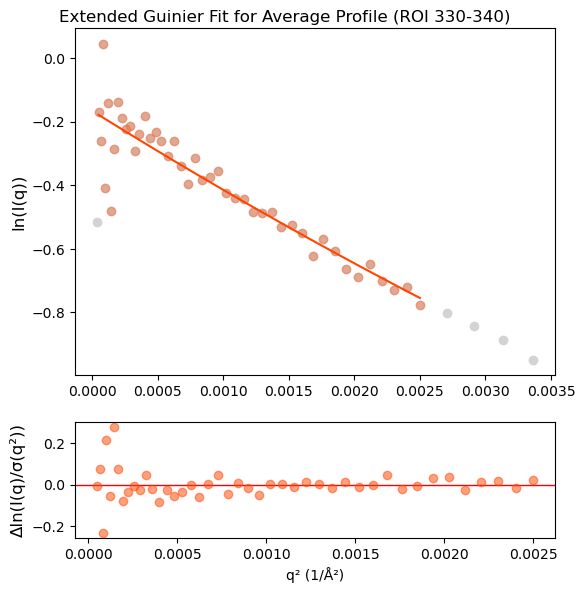

In [78]:
# Plot the q and intensity data from Manual Guinier plot (ln(I) vs q^2)

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)


# Square the q values and take the natural logarithm of the intensity
q_sq = q ** 2
I_ln = np.log(intensity)

# plot the data points for context
max_q = len(qrange)
# mask = (q >= qrange[0]) & (q <= qrange[max_q+10])

start_idx = 0
end_idx = max_q

mask = np.zeros(len(q), dtype=bool)
mask[max(0, start_idx-1):min(len(q), end_idx+5)] = True

axs[0].plot(q_sq[mask], I_ln[mask], marker='o', 
         linestyle='None', color='lightgray', label='Data')
axs[0].set_ylabel('ln(I(q))', fontsize=12)


# Plot the ExtendedGuinier fit data points
axs[0].plot(qrange**2, log_Iq, marker='o', linestyle='None',
            label='Guinier points', color=colorAA, alpha=0.3)
axs[0].plot(qrange**2, log_Iq_fit, linestyle='-', color=colorAA, label='Extended Guinier fit')



# Plot residuals in second subplot
axs[1].plot(qrange**2, residuals, marker='o', 
            linestyle='None', color=colorAA, alpha=0.5)

# Set up labels for residuals subplot
axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
axs[1].tick_params(axis='both', labelsize=10)
    
plt.xlabel('q² (1/Å²)')
plt.suptitle(f'Extended Guinier Fit for Average Profile (ROI {roi_start}-{roi_end})')
plt.show()

# IGNORE

In [ ]:
# extended guinier loop

results = []

for profile in sub_profiles_roi:

    eg = ExtendedGuinier(
        profile.getQ(),
        profile.getI(),
        profile.getErr()
    )

    results.append(
        eg.analyze(Nres=121)
    )